In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')

from src.auto_encoder import AutoEncoder
from src.config import Config
from src.data import DataSet, DataSetType, SampleDataSet, MelSpectrogramDataSet, ExtractedFeaturesDataSet
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from src.models.lstm import LSTMEncoder, LSTMDecoder, Encoder, Decoder


In [78]:
dataset = SampleDataSet(dataset_type=DataSetType.INTRA, split='train', data_transform='raw', prefix='..')

initializing dataset: 100%|██████████| 32/32 [00:01<00:00, 29.25it/s]


In [79]:
dataset_mel = MelSpectrogramDataSet(
    dataset_type=DataSetType.INTRA,
    split='train',
    prefix='..'
)

Computing mean and std: 100%|██████████| 7936/7936 [00:04<00:00, 1809.03it/s]

Found 7936 files in folder ../data/mel_spectograms_cache/intra/train


tensor([[-3.6827, -3.6827, -3.6827,  ..., -3.6827, -3.6827, -3.6827],
        [ 3.5003,  3.3524,  3.4648,  ...,  3.6246,  3.6514,  3.5695],
        [ 2.2683,  2.1204,  2.2328,  ...,  2.3926,  2.4195,  2.3375],
        ...,
        [ 0.3455,  0.3322, -0.3413,  ...,  0.4019,  0.2170,  0.4722],
        [ 0.2630,  0.2739, -0.2099,  ...,  0.3431,  0.3304,  0.4232],
        [ 0.0401,  0.2940,  0.3748,  ...,  0.3593,  0.8896,  0.5066]])

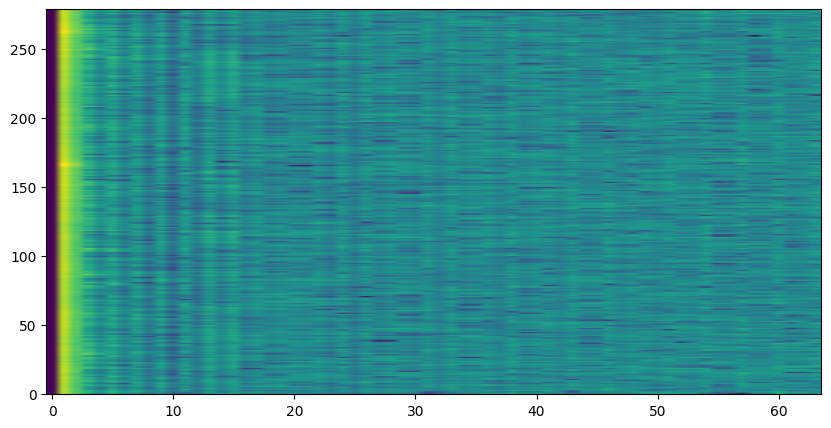

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(dataset_mel[0].numpy().T, origin='lower', aspect='auto')

dataset_mel[0] #/ dataset_mel[0].std()


In [81]:
dataset[0][0].shape
# dataset.load()

torch.Size([35624, 248])

In [82]:
# convert to mel frequency spectrum
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB

In [83]:
len(dataset)

32

In [84]:
dataset[0][0][:, 29].shape

torch.Size([35624])

Data shape: torch.Size([35624])
MAE from index 0: 0.26771605014801025


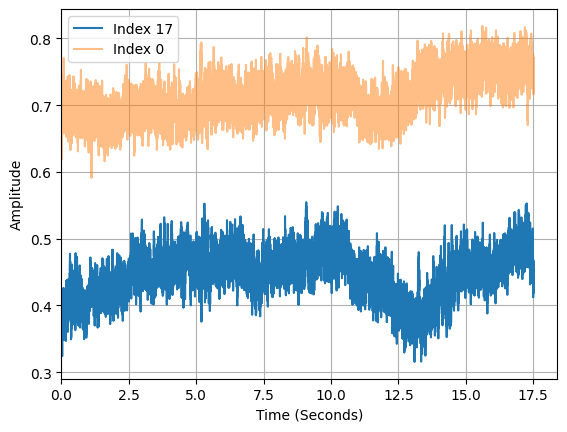

In [85]:
# plot raw data
import matplotlib.pyplot as plt
import torch

INDEX = 17
DATA_INDEX = 0

print('Data shape:', dataset[DATA_INDEX][0][:, INDEX].shape)
print("MAE from index 0:", torch.abs(dataset[DATA_INDEX][0][:, INDEX] - dataset[DATA_INDEX][0][:, 0]).mean().item())

_time = torch.arange(dataset[DATA_INDEX][0][:, INDEX].shape[0]) / 2034

plt.plot(_time, dataset[DATA_INDEX][0][:, INDEX], label=f'Index {INDEX}')
plt.plot(_time, dataset[DATA_INDEX][0][:, 0], label=f'Index 0', alpha=0.5)
# plt.scatter(np.linsadataset[DATA_INDEX][0][:, 0], label=f'Index 0', alpha=0.5)

# plt.gca().set_xlim(150, 200)
plt.gca().set_xlim(0, None)

ax = plt.gca()
ymin, ymax = ax.get_ylim()
# for i in range(200):
#     ax.vlines(8*(i+1), ymin, ymax, color='red', alpha=0.5, linestyle='--')
    
# ax.set_ylim(-0.5, 1)
ax.grid(True)
ax.legend()

ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Amplitude')

# ax.set_title(f'Index {INDEX} and Index 0')

plt.savefig('plots/raw_data.png', dpi=300)
plt.show()

In [86]:
# Try using a larger n_fft and n_mels so that you have enough frequency resolution.
# Try different parameters! If all energy falls in the first mel band, the frequency coverage or energy windowing is too coarse for this data.
# Try lowering n_fft and/or n_mels to match the limited frequency content (sample_rate=128Hz), and experiment with normalization and power.
# According to torchaudio docs, typical mel calculations work for speech-like sample_rates (8kHz+). For low sample_rates, only a few mels make sense.
mel_transform = MelSpectrogram(
    sample_rate=2034,
    n_fft=256,
    n_mels=8,
    hop_length=64,
    # power=2.0,
    f_min=4.0,
    f_max=40.0,
    # pad=3,
    # normalized=False,
    # center=True,
    # pad_mode='reflect',
    # onesided=True,
    # norm='slaney',
    # mel_scale='htk'
)

db_transform = AmplitudeToDB(stype='power', top_db=80.0)

In [87]:
dataset[0][0].shape[1]

248

In [88]:
dataset[0][0][:, INDEX].shape

torch.Size([35624])

torch.Size([8, 557])
torch.Size([8, 557])


Text(0.5, 1.0, 'Mel Spectrogram for index 0')

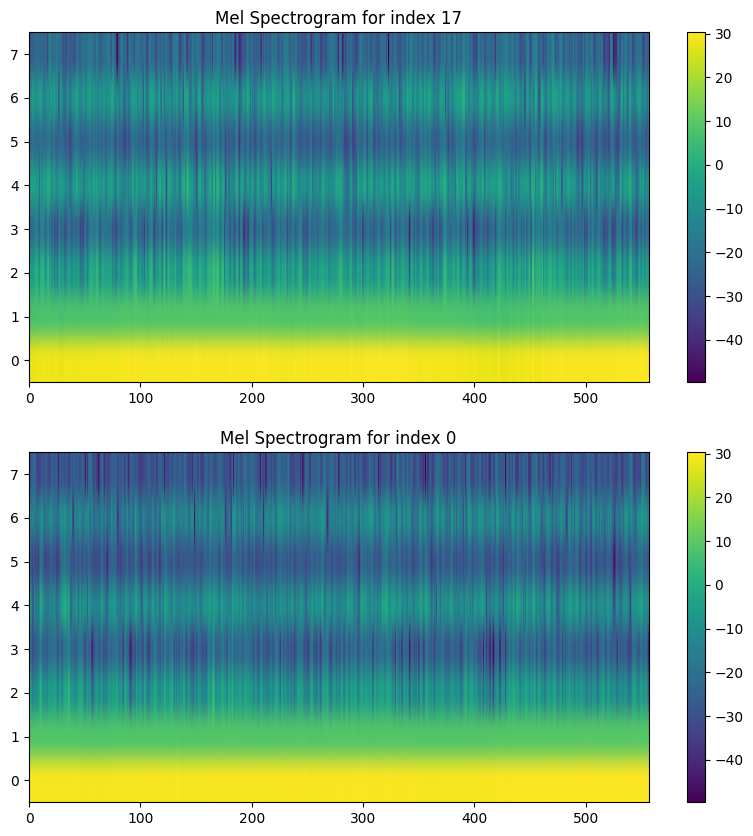

In [59]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

SCALE = 1

x_transformed = mel_transform(dataset[0][0][:, INDEX] * SCALE)
print(x_transformed.shape)

x_transformed = x_transformed.reshape(x_transformed.size(0), -1)
x_transformed.shape

x_transformed = db_transform(x_transformed)

# x_transformed = torch.log(x_transformed + 1e-10)


im0 = ax[0].imshow(x_transformed.numpy(), origin='lower', aspect='auto')
fig.colorbar(im0, ax=ax[0])
ax[0].set_title(f'Mel Spectrogram for index {INDEX}')

x_transformed = mel_transform(dataset[0][0][:, 0] * SCALE)
print(x_transformed.shape)

x_transformed = x_transformed.reshape(x_transformed.size(0), -1)
x_transformed.shape

x_transformed = db_transform(x_transformed)

ax[1].imshow(x_transformed.numpy(), origin='lower', aspect='auto')
fig.colorbar(im0, ax=ax[1])
ax[1].set_title('Mel Spectrogram for index 0')

In [60]:
x = dataset_mel[0]
x.shape, x

(torch.Size([64, 279]),
 tensor([[-3.6827, -3.6827, -3.6827,  ..., -3.6827, -3.6827, -3.6827],
         [ 3.5003,  3.3524,  3.4648,  ...,  3.6246,  3.6514,  3.5695],
         [ 2.2683,  2.1204,  2.2328,  ...,  2.3926,  2.4195,  2.3375],
         ...,
         [ 0.3455,  0.3322, -0.3413,  ...,  0.4019,  0.2170,  0.4722],
         [ 0.2630,  0.2739, -0.2099,  ...,  0.3431,  0.3304,  0.4232],
         [ 0.0401,  0.2940,  0.3748,  ...,  0.3593,  0.8896,  0.5066]]))

In [10]:
encoder = LSTMEncoder(input_size=64, hidden_size=8, num_layers=4, bidirectional=False)
decoder = LSTMDecoder(output_size=64, hidden_size=8, num_layers=4, bidirectional=False)
x_prime = x.T.unsqueeze(0)
print('X_prime:', x_prime.shape)
z = encoder(x_prime)

X_prime: torch.Size([1, 279, 64])


## Load Embeddings

In [16]:
config = Config()
encoder = Encoder(input_size=config.num_features, hidden_size=config.hidden_size, num_layers=config.num_layers, dropout=config.dropout, bidirectional=config.bidirectional)
decoder = Decoder(output_size=config.num_features, hidden_size=config.hidden_size, num_layers=config.num_layers, dropout=config.dropout, bidirectional=config.bidirectional)

model = AutoEncoder(encoder=encoder, decoder=decoder, config=config)

In [17]:
config

Config(data_type='intra', data_transform='mel', learning_rate=0.0001, batch_size=32, num_workers=4, max_epochs=20, val_check_interval=1.0, enable_checkpointing=True, enable_progress_bar=True, enable_model_summary=True, accelerator='cpu', log_every_n_steps=1, early_stopping_patience=2, early_stopping_min_delta=0.001, stochastic_weight_averaging_swa_lrs=0.001, stochastic_weight_averaging_swa_epoch_start=5, weight_mse=1, weight_contrastive=0.1, increase_contrastive_weight_every_epoch=True, base_channels=128, latent_dim=64, num_features=64, hidden_size=8, num_layers=4, dropout=0.2, bidirectional=True)

In [18]:
model.encoder

Encoder(
  (lstm_enc): LSTM(64, 8, num_layers=4, batch_first=True, dropout=0.2, bidirectional=True)
)

In [19]:
state_dict = torch.load(f'../logs/lightning_logs/version_17/checkpoints/last.ckpt')
model.load_state_dict(state_dict['state_dict'])

<All keys matched successfully>

In [20]:
x = dataset_mel[0]

In [21]:
emb = model.encoder(x.T.unsqueeze(0))
emb.shape

torch.Size([1, 279, 16])

In [22]:
dataset_mel.return_labels = True

In [68]:
dataset_mel[0]

embs = []
file_indices = []
sensor_indices = []

with torch.no_grad():
    for i in tqdm(range(len(dataset_mel)), total=len(dataset_mel), desc='Embedding'):
        x, file_index, sensor_index = dataset_mel[i]
        
        # last one
        emb = model.encoder(x.T.unsqueeze(0))[:, -1, :]#.squeeze(0)
        # print(emb.shape)
        embs.append(emb)
        
        file_indices.append(file_index)
        sensor_indices.append(sensor_index)
        
        # break
        
        # if i > 500: 
        #     break
    

Embedding: 100%|██████████| 7936/7936 [01:45<00:00, 75.38it/s]


In [72]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

In [77]:
dataset_mel_train = MelSpectrogramDataSet(
    dataset_type=DataSetType.INTRA,
    split='train',
    prefix='..'
)
dataset_mel_test = MelSpectrogramDataSet(
    dataset_type=DataSetType.INTRA,
    split='test',
    prefix='..'
)
dataset_mel_test.get_mean_and_std(dataset_mel_train)

dataset_mel_test.return_labels = True

Computing mean and std: 100%|██████████| 7936/7936 [00:04<00:00, 1779.99it/s]

Found 7936 files in folder ../data/mel_spectograms_cache/intra/train
Found 1984 files in folder ../data/mel_spectograms_cache/intra/test


In [83]:
# dataset_mel[0]

embs_test = []
file_indices_test = []
sensor_indices_test = []

with torch.no_grad():
    for i in tqdm(range(len(dataset_mel_test)), total=len(dataset_mel_test), desc='Embedding'):
        x, file_index, sensor_index = dataset_mel_test[i]
        
        # last one
        # emb = model.encoder(x.T.unsqueeze(0))[:, -1, :]#.squeeze(0)
        emb = model.encoder(x.T.unsqueeze(0)).mean(dim=1)#.squeeze(0)
        # print(emb.shape)
        # break
        embs_test.append(emb)
        
        file_indices_test.append(file_index)
        sensor_indices_test.append(sensor_index)
    

Embedding: 100%|██████████| 1984/1984 [00:25<00:00, 77.32it/s]


In [84]:
# compute t-sne embedding
all_embs_test = torch.cat(embs_test, dim=0).numpy()
print(all_embs_test.shape)

(1984, 16)


In [85]:
tsne = TSNE(n_components=2, random_state=42)
tsne_result_test = tsne.fit_transform(all_embs_test) # type: ignore
print(tsne_result_test.shape)

(1984, 2)


In [70]:
# compute t-sne embedding
all_embs = torch.cat(embs, dim=0).numpy()
print(all_embs.shape)

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(all_embs) # type: ignore
print(tsne_result.shape)

(7936, 16)
(7936, 2)


In [73]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(all_embs) # type: ignore
print(pca_result.shape)

(7936, 2)


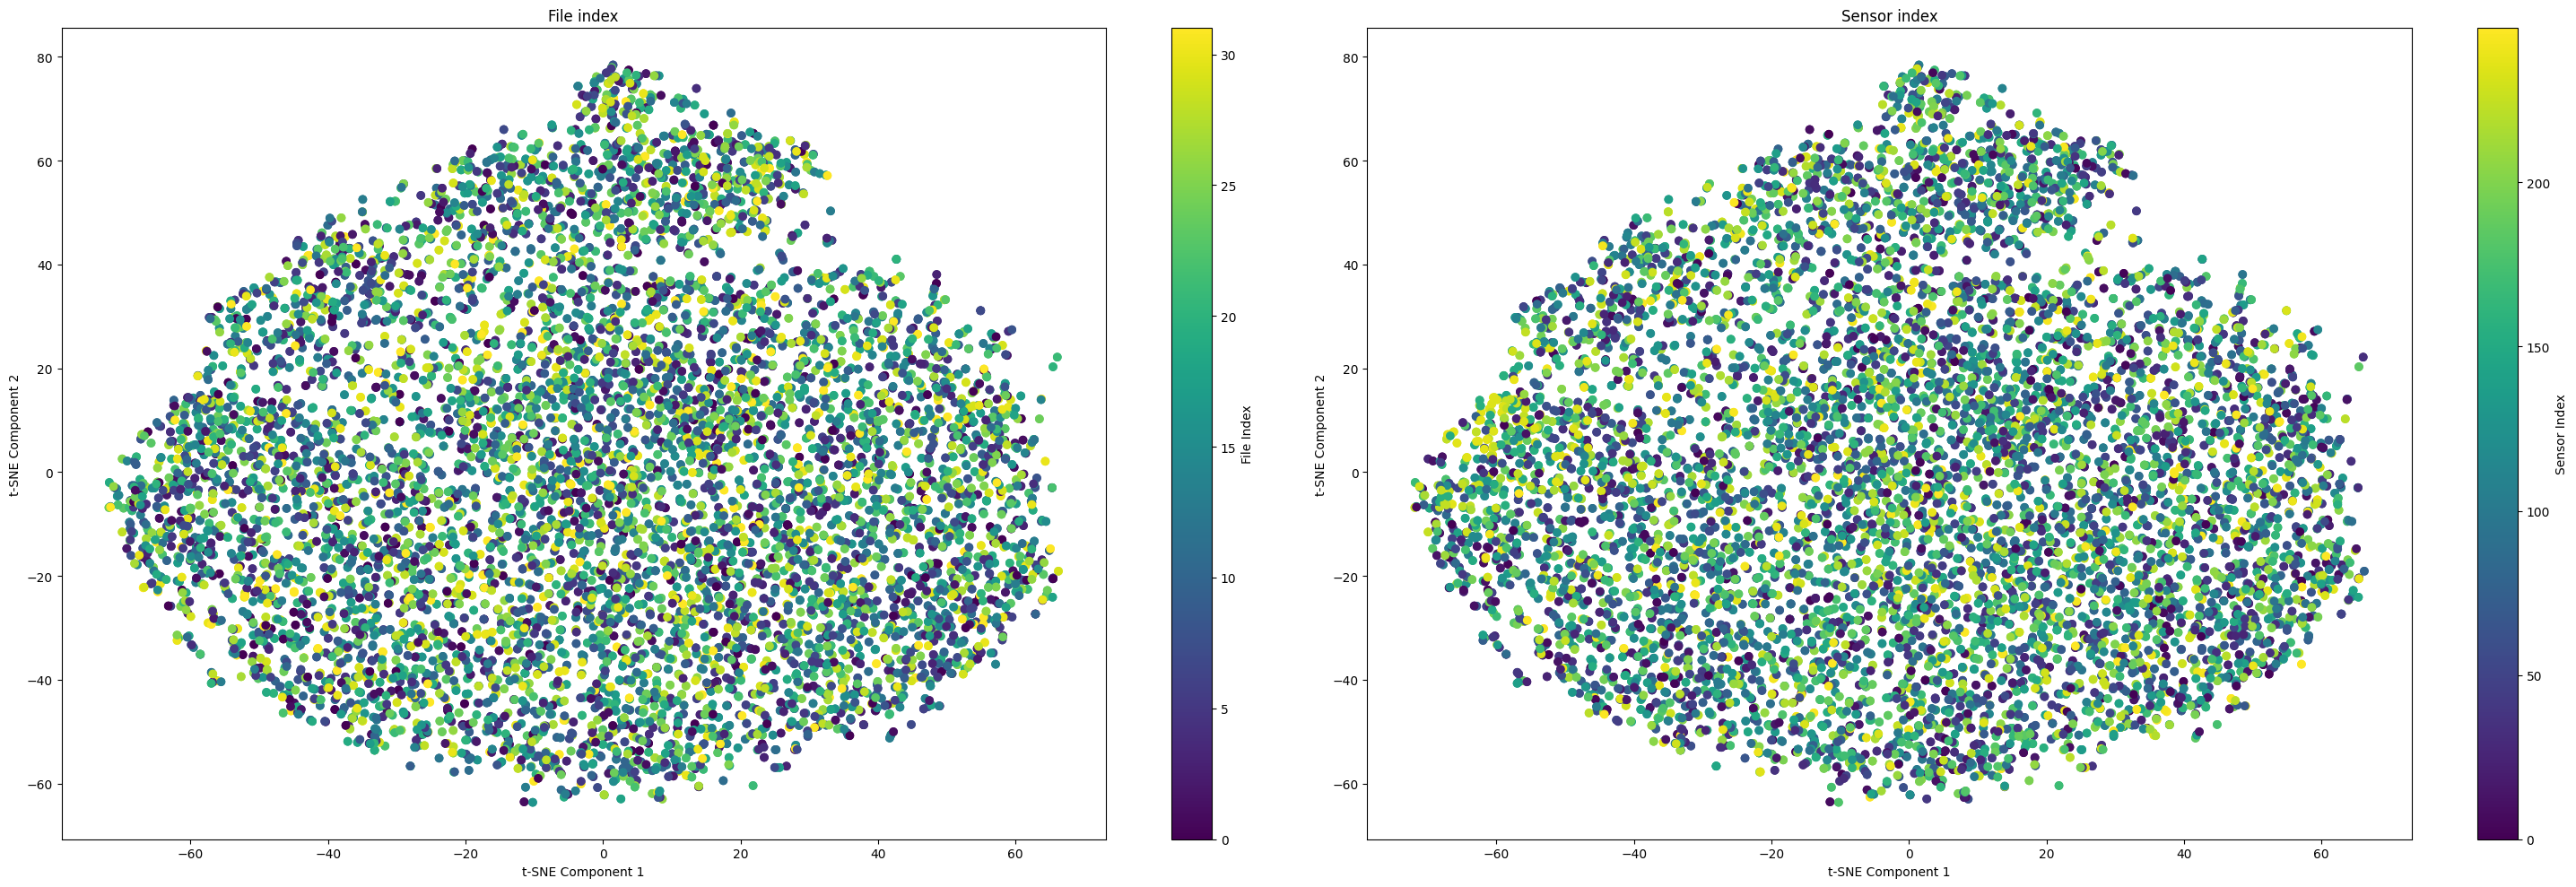

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
ax[0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=file_indices, cmap='viridis')
sc = ax[0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=file_indices, cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='File Index')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('File index')

ax[1].scatter(tsne_result[:, 0], tsne_result[:, 1], c=sensor_indices, cmap='viridis')
sc = ax[1].scatter(tsne_result[:, 0], tsne_result[:, 1], c=sensor_indices, cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Sensor Index')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Sensor index')


fig.tight_layout()
plt.show()


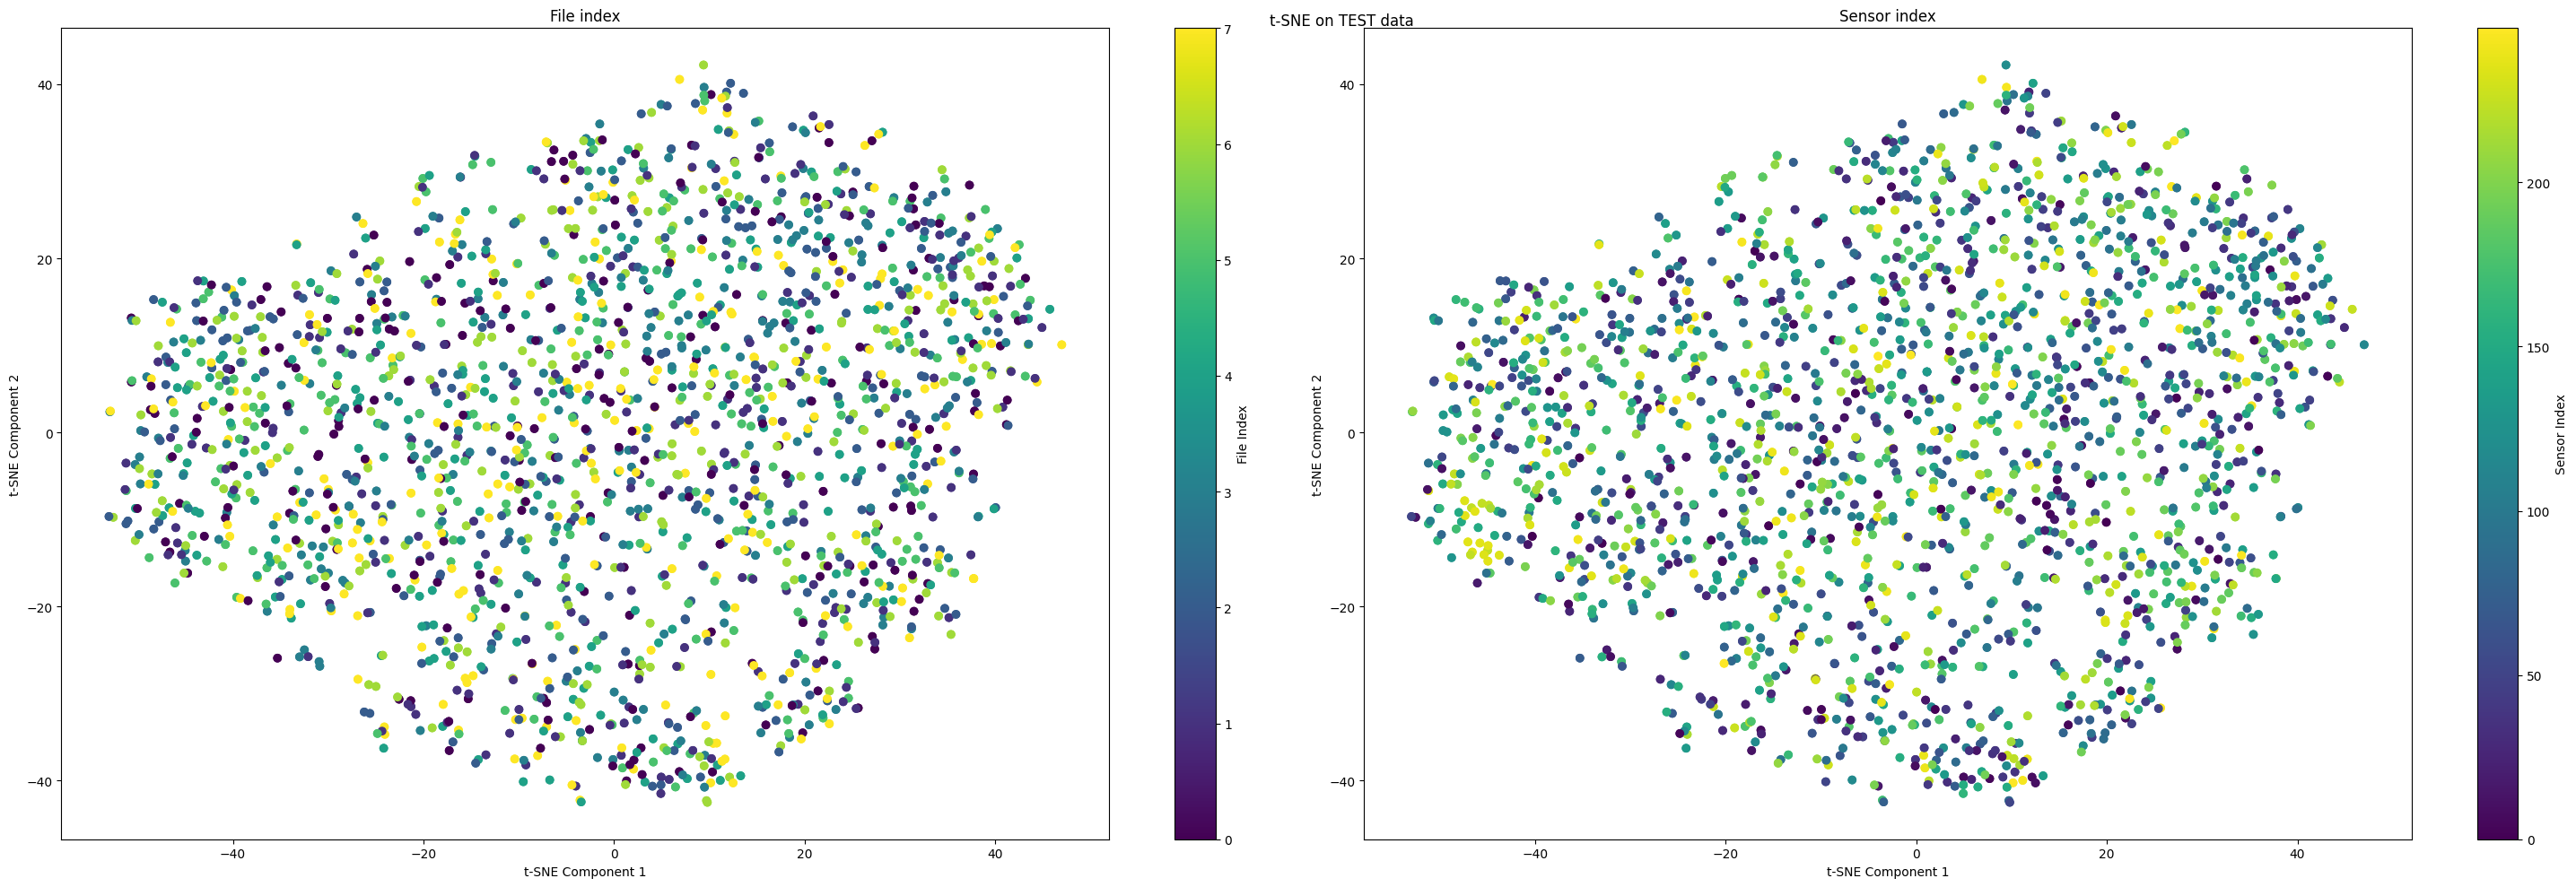

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=file_indices_test, cmap='viridis')
sc = ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=file_indices_test, cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='File Index')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('File index')

ax[1].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=sensor_indices_test, cmap='viridis')
sc = ax[1].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=sensor_indices_test, cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Sensor Index')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Sensor index')


fig.tight_layout()
fig.suptitle('t-SNE on TEST data')
plt.show()


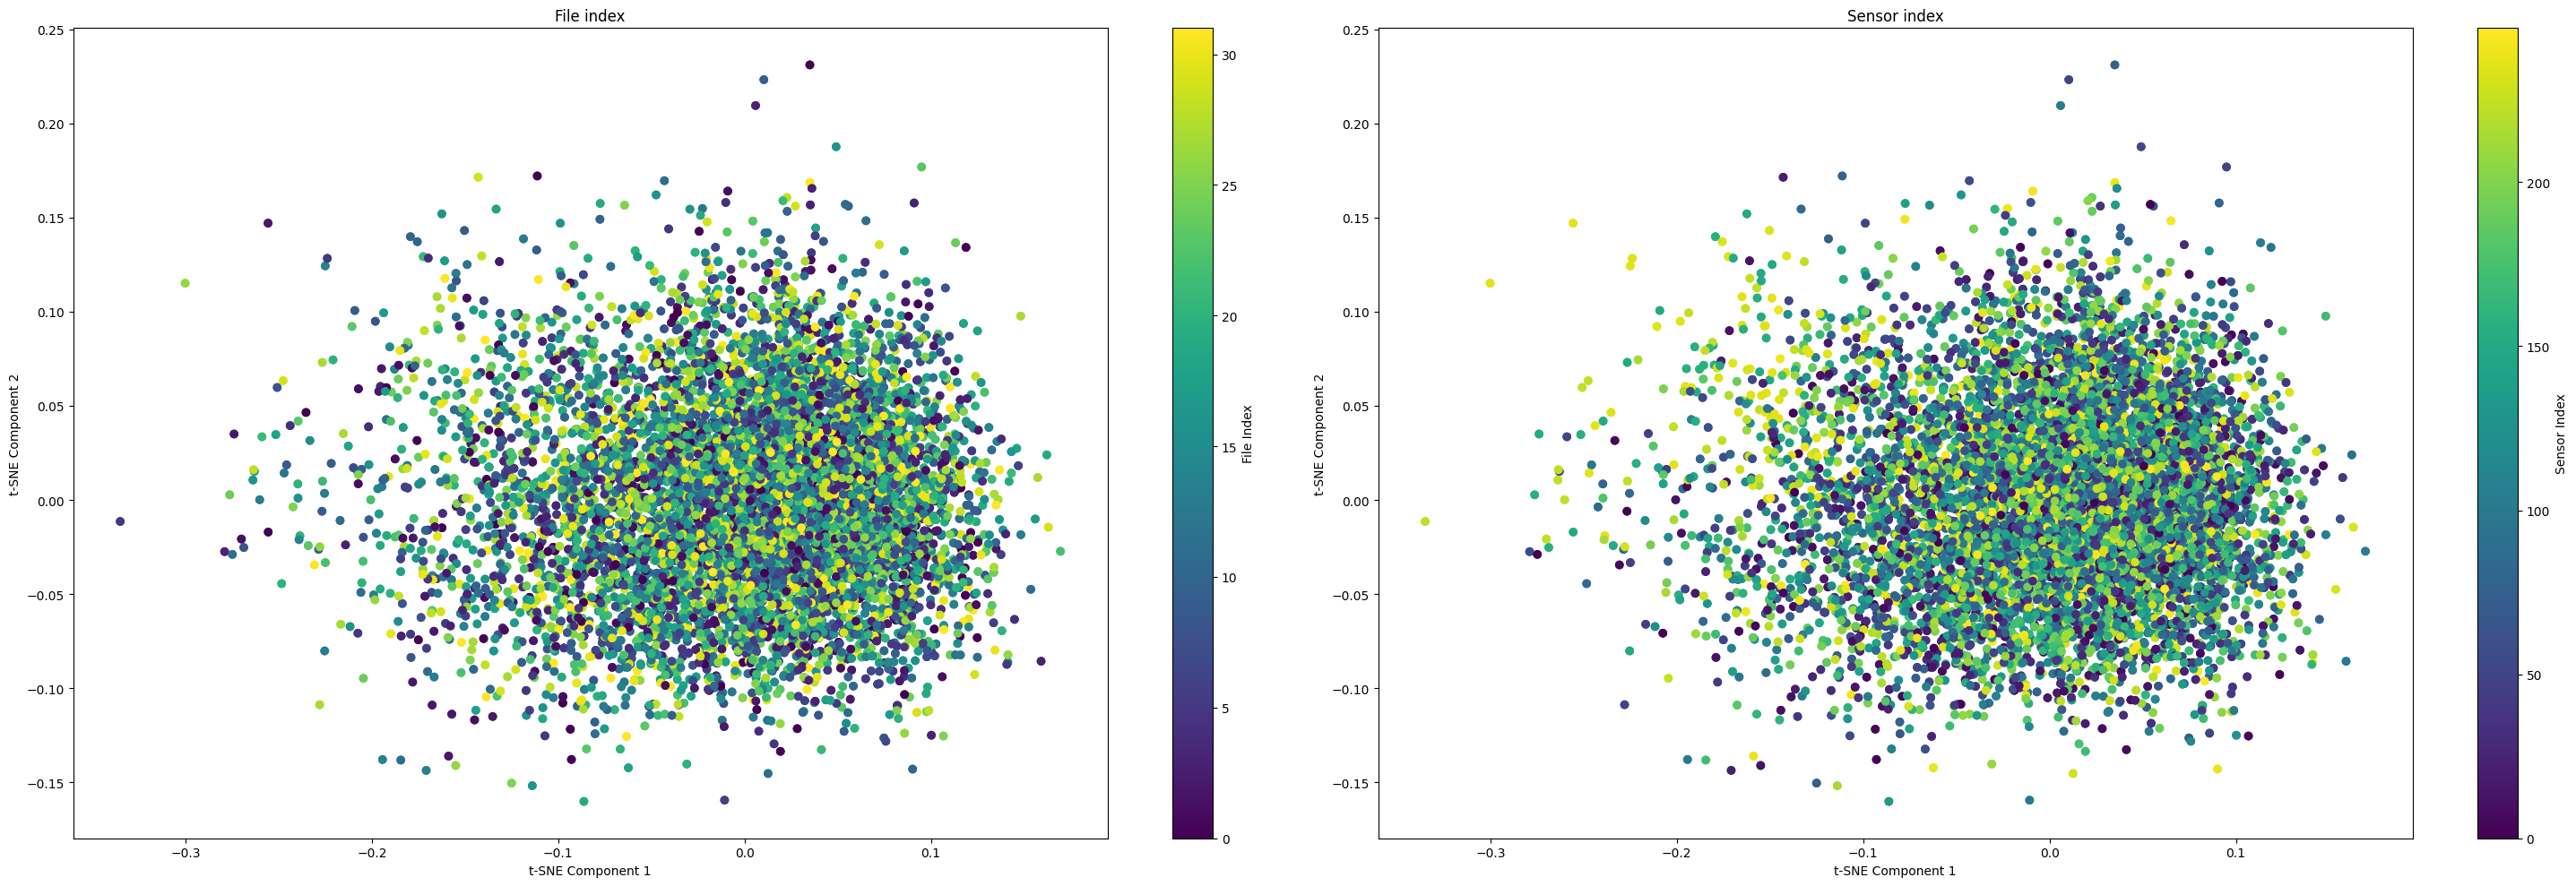

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
ax[0].scatter(pca_result[:, 0], pca_result[:, 1], c=file_indices, cmap='viridis')
sc = ax[0].scatter(pca_result[:, 0], pca_result[:, 1], c=file_indices, cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='File Index')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('File index')

ax[1].scatter(pca_result[:, 0], pca_result[:, 1], c=sensor_indices, cmap='viridis')
sc = ax[1].scatter(pca_result[:, 0], pca_result[:, 1], c=sensor_indices, cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Sensor Index')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Sensor index')


fig.tight_layout()
plt.show()


## Best LSTM encoder

In [63]:
import yaml

def extend_from_config(config: Config, config_file: str):
    print('Extending config from', config_file)
    
    with open(config_file, 'r') as f:
        config_dict = yaml.safe_load(f)
        
    for key, value in config_dict.items():
        if hasattr(config, key):
            setattr(config, key, value)
        else:
            raise ValueError(f"Key {key} not found in config")

In [64]:
config = Config()
extend_from_config(config, '../configs/Intra/lstm/lstm_128_true_1.yaml')

encoder = Encoder(input_size=config.num_features, hidden_size=config.hidden_size, num_layers=config.num_layers, dropout=config.dropout, bidirectional=config.bidirectional)
decoder = Decoder(output_size=config.num_features, hidden_size=config.hidden_size, num_layers=config.num_layers, dropout=config.dropout, bidirectional=config.bidirectional)
    
model = AutoEncoder(encoder=encoder, decoder=decoder, config=config)
# load the checkpoint
model.load_state_dict(torch.load(f'../logs/lstm_128_true_1/version_0/checkpoints/last.ckpt')['state_dict'])
# /Users/felix/UU-Deep-Learning-2026-Assignment-2/logs/lstm_128_true_1/version_0/checkpoints/epoch=3-step=248.ckpt

Extending config from ../configs/Intra/lstm/lstm_128_true_1.yaml


/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


<All keys matched successfully>

In [65]:
dataset_mel_train = MelSpectrogramDataSet(
    dataset_type=DataSetType.INTRA,
    split='train',
    prefix='..'
)
dataset_mel_test = MelSpectrogramDataSet(
    dataset_type=DataSetType.INTRA,
    split='test',
    prefix='..'
)
dataset_mel_test.get_mean_and_std(dataset_mel_train)

dataset_mel_test.return_labels = True

Computing mean and std: 100%|██████████| 7936/7936 [00:02<00:00, 3173.94it/s]

Found 7936 files in folder ../data/mel_spectograms_cache/intra/train
Found 1984 files in folder ../data/mel_spectograms_cache/intra/test


In [66]:
# dataset_mel[0]

embs_test = []
file_indices_test = []
sensor_indices_test = []

with torch.no_grad():
    for i in tqdm(range(len(dataset_mel_test)), total=len(dataset_mel_test), desc='Embedding'):
        x, file_index, sensor_index = dataset_mel_test[i]
        
        # last one
        emb = model.encoder(x.T.unsqueeze(0))[:, -1, :]#.squeeze(0)
        # emb = model.encoder(x.T.unsqueeze(0)).mean(dim=1)#.squeeze(0)
        # print(emb.shape)
        # break
        embs_test.append(emb)
        
        file_indices_test.append(file_index)
        sensor_indices_test.append(sensor_index)
    

Embedding:   0%|          | 0/1984 [00:00<?, ?it/s]

Embedding: 100%|██████████| 1984/1984 [00:12<00:00, 153.65it/s]


In [67]:
# compute t-sne embedding
all_embs_test = torch.cat(embs_test, dim=0).numpy()
print(all_embs_test.shape)

tsne = TSNE(n_components=2, random_state=42)
tsne_result_test = tsne.fit_transform(all_embs_test) # type: ignore
print(tsne_result_test.shape)

(1984, 256)


NameError: name 'TSNE' is not defined

In [ ]:
file_to_task = {
    0: 0,
    1: 0,
    2: 1,
    3: 1,
    4: 2,
    5: 2, 
    6: 3, 
    7: 3
}

label_indices_test = [file_to_task[i] for i in file_indices_test]

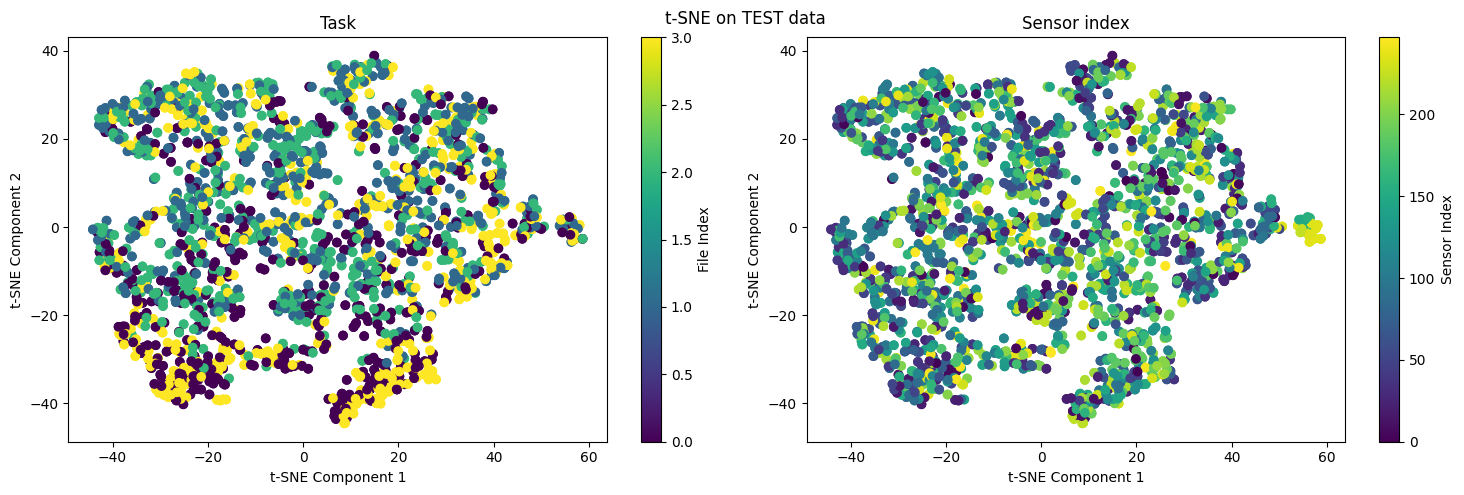

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=file_indices_test, cmap='viridis')
ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=label_indices_test, cmap='viridis')
sc = ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=label_indices_test, cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='File Index')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('Task')

ax[1].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=sensor_indices_test, cmap='viridis')
sc = ax[1].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=sensor_indices_test, cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Sensor Index')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Sensor index')


fig.tight_layout()
fig.suptitle('t-SNE on TEST data')
fig.savefig('plots/t-sne_lstm_embeddings.png', dpi=300)
plt.show()


## Test ExtractedFeaturesDataSet

In [168]:
# for the 
dataset_sample = SampleDataSet(dataset_type=DataSetType.INTRA, split='train',
                               prefix='..')

initializing dataset: 100%|██████████| 32/32 [00:01<00:00, 26.33it/s]


In [169]:
dataset_mel = MelSpectrogramDataSet(dataset_type=DataSetType.INTRA, split='train', prefix='..')

Computing mean and std: 100%|██████████| 7936/7936 [00:04<00:00, 1587.99it/s]

Found 7936 files in folder ../data/mel_spectograms_cache/intra/train


In [170]:
dataset_mel.std

tensor(9.9123)

ExtractedFeaturesDataSet

In [171]:
dataset_extracted = ExtractedFeaturesDataSet(
    dataset_type=DataSetType.INTRA,
    split='train',
    prefix='..'
)
dataset_extracted.from_sample_dataset(dataset_sample)
dataset_extracted.get_mel_mean_and_std(dataset_mel)

Extending config from /Users/felix/UU-Deep-Learning-2026-Assignment-2/configs/Intra/lstm/lstm_128_true_1.yaml


/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(
/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [172]:
all_embeddings = []
labels = []

for i in tqdm(range(len(dataset_extracted)), total=len(dataset_extracted), desc='Embedding'):
    embeddings, label = dataset_extracted[i]
    all_embeddings.append(embeddings.unsqueeze(0))
    labels.append(label)

all_embeddings = torch.cat(all_embeddings, dim=0)
labels = torch.tensor(labels)

Embedding: 100%|██████████| 32/32 [00:54<00:00,  1.70s/it]


In [173]:
all_embeddings.shape, labels.shape

(torch.Size([32, 63488]), torch.Size([32]))

In [148]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

In [174]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)

In [149]:
tsne_result_test = tsne.fit_transform(all_embeddings.detach().numpy()) # type: ignore

In [175]:
pca_result = pca.fit_transform(all_embeddings.detach().numpy()) # type: ignore
pca_result.shape

(32, 2)

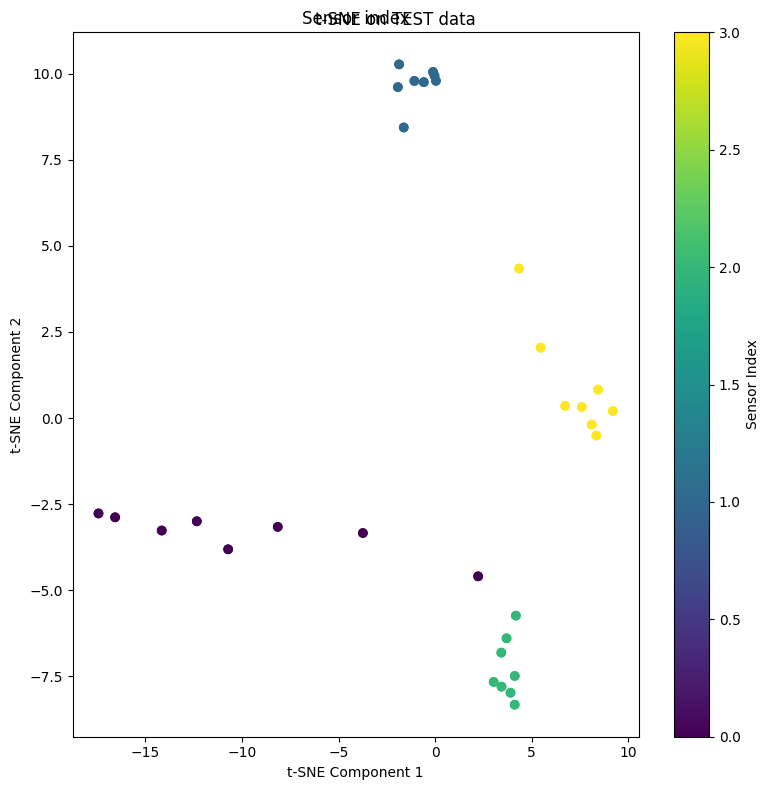

In [176]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))


# ax.scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=labels.numpy(), cmap='viridis')
# sc = ax.scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=labels.numpy(), cmap='viridis')
# plt.colorbar(sc, ax=ax, label='Sensor Index')
# ax.set_xlabel('t-SNE Component 1')
# ax.set_ylabel('t-SNE Component 2')
# ax.set_title('Sensor index')

ax.scatter(pca_result[:, 0], pca_result[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax.scatter(pca_result[:, 0], pca_result[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax, label='Sensor Index')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('Sensor index')


fig.tight_layout()
fig.suptitle('t-SNE on TEST data')
# fig.savefig('plots/t-sne_lstm_embeddings.png', dpi=300)
plt.show()


In [177]:
dataset_extracted_test = ExtractedFeaturesDataSet(
    dataset_type=DataSetType.INTRA,
    split='test',
    prefix='..'
)
dataset_extracted_test.from_same_dataset(dataset_extracted)
# dataset_extracted.from_sample_dataset(dataset_sample)
# dataset_extracted.get_mel_mean_and_std(dataset_mel)

Extending config from /Users/felix/UU-Deep-Learning-2026-Assignment-2/configs/Intra/lstm/lstm_128_true_1.yaml


/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(
/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [152]:
all_embeddings_test = []
labels_test = []

for i in tqdm(range(len(dataset_extracted_test)), total=len(dataset_extracted_test), desc='Embedding'):
    embeddings, label = dataset_extracted_test[i]
    all_embeddings_test.append(embeddings.unsqueeze(0))
    labels_test.append(label)

all_embeddings_test = torch.cat(all_embeddings_test, dim=0)
labels_test = torch.tensor(labels_test)
all_embeddings_test.shape, labels_test.shape

Embedding: 100%|██████████| 8/8 [00:13<00:00,  1.70s/it]


(torch.Size([8, 63488]), torch.Size([8]))

In [166]:
# To avoid ValueError: perplexity must be less than n_samples
n_samples = all_embeddings_test.shape[0]
perplexity = min(30, max(1, n_samples - 1))  # Use at most 30, but less if fewer samples

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
tsne_result_testset = tsne.fit_transform(all_embeddings_test.detach().numpy()) # type: ignore
tsne_result_testset.shape

(8, 2)

In [179]:
pca_result_testset = pca.transform(all_embeddings_test.detach().numpy()) # type: ignore
pca_result_testset.shape

(8, 2)

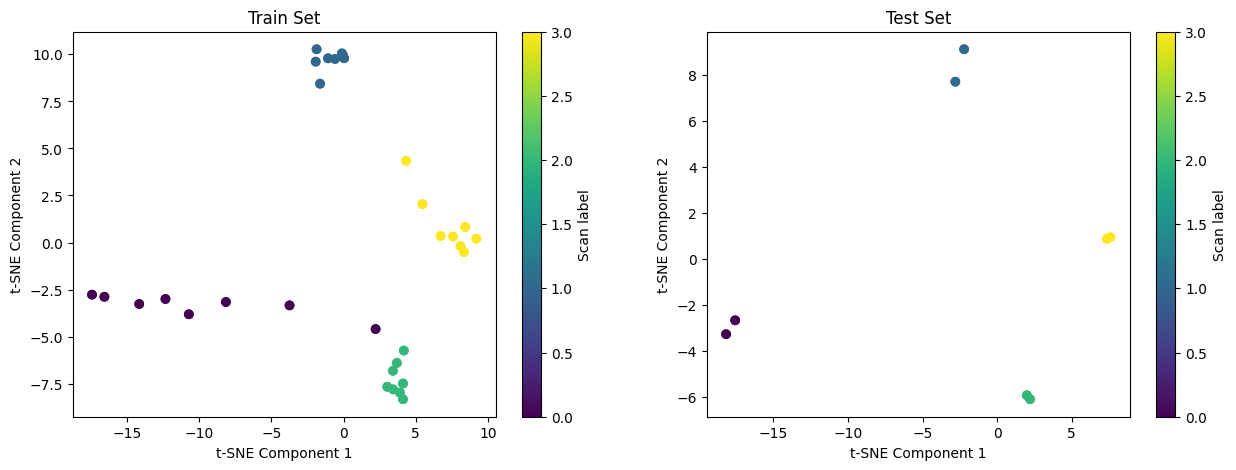

In [182]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(pca_result[:, 0], pca_result[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0].scatter(pca_result[:, 0], pca_result[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('Train Set')

ax[1].scatter(pca_result_testset[:, 0], pca_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
sc = ax[1].scatter(pca_result_testset[:, 0], pca_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Test Set')

fig.savefig('plots/pca_extracted_features.png', dpi=300)

plt.show()


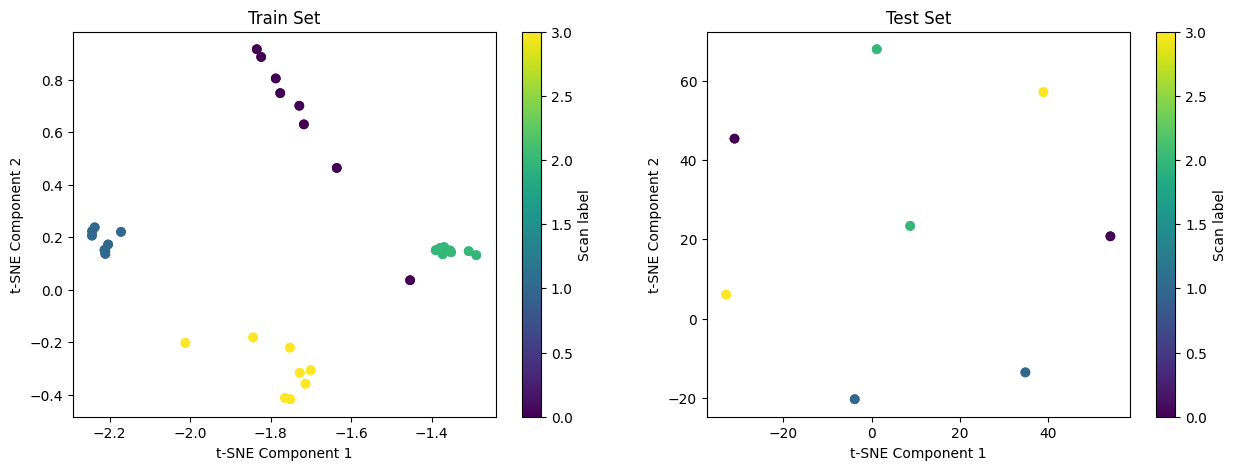

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('Train Set')

ax[1].scatter(tsne_result_testset[:, 0], tsne_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
sc = ax[1].scatter(tsne_result_testset[:, 0], tsne_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Test Set')



plt.show()


## Train k-nearest neighbor

In [ ]:
from sklearn.cluster import KMeans

In [195]:
kmeans = KMeans(n_clusters=4)

# train
kmeans.fit(all_embeddings.detach().numpy())
kmeans_labels = kmeans.labels_

# test
labels_test = kmeans.predict(all_embeddings_test.detach().numpy())

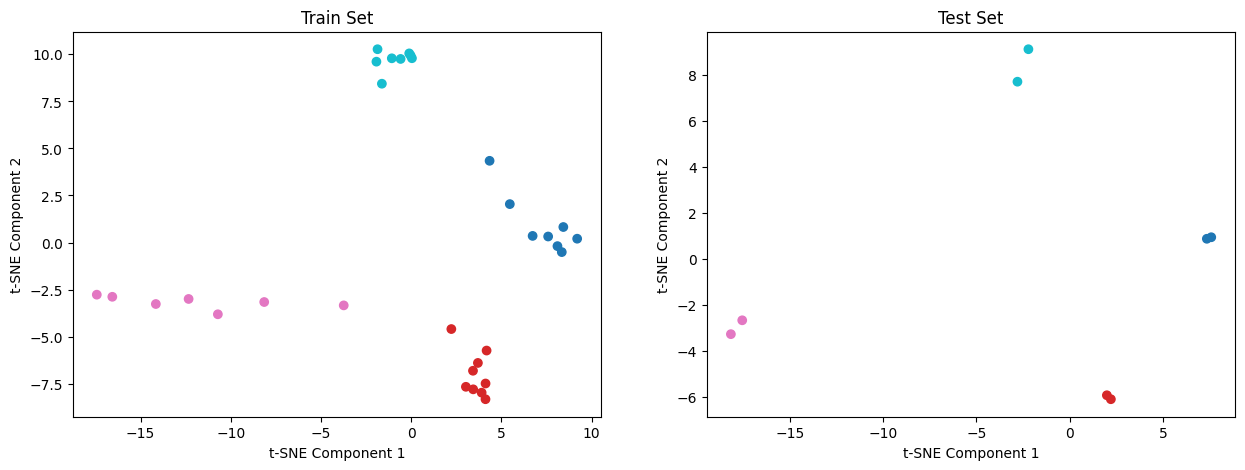

In [197]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sc = ax[0].scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, cmap='tab10')
# sc = ax[0].scatter(tsne_result_test[:, 0], tsne_result_test[:, 1], c=labels.numpy(), cmap='viridis')
# plt.colorbar(sc, ax=ax[0], label='cluster label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('Train Set')
# ax[0].legend()

ax[1].scatter(pca_result_testset[:, 0], pca_result_testset[:, 1], c=labels_test, cmap='tab10')
# sc = ax[1].scatter(tsne_result_testset[:, 0], tsne_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
# plt.colorbar(sc, ax=ax[1], label='cluster label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('Test Set')
fig.savefig('plots/kmeans_extracted_features.png', dpi=300)
plt.show()

## OOD Investigtion

In [198]:
dataset_extracted_cross = ExtractedFeaturesDataSet(
    dataset_type=DataSetType.CROSS,
    split='train',
    prefix='..'
)
dataset_extracted_cross.from_sample_dataset(dataset_sample)
# dataset_extracted.from_sample_dataset(dataset_sample)
# dataset_extracted.get_mel_mean_and_std(dataset_mel)

Extending config from /Users/felix/UU-Deep-Learning-2026-Assignment-2/configs/Intra/lstm/lstm_128_true_1.yaml


/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(
/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [207]:
all_embeddings_cross = []
labels_cross = []

for i in tqdm(range(len(dataset_extracted_cross)), total=len(dataset_extracted_cross), desc='Embedding'):
    embeddings, label = dataset_extracted_cross[i]
    all_embeddings_cross.append(embeddings.unsqueeze(0))
    labels_cross.append(label)

all_embeddings_cross = torch.cat(all_embeddings_cross, dim=0)
labels_cross = torch.tensor(labels_cross)

Embedding: 100%|██████████| 64/64 [01:44<00:00,  1.63s/it]


In [210]:
pca_result_cross = pca.transform(all_embeddings_cross.detach().numpy()) # type: ignore
pca_result_cross.shape

(64, 2)

In [212]:
labels_cross_kmeans = kmeans.predict(all_embeddings_cross.detach().numpy())

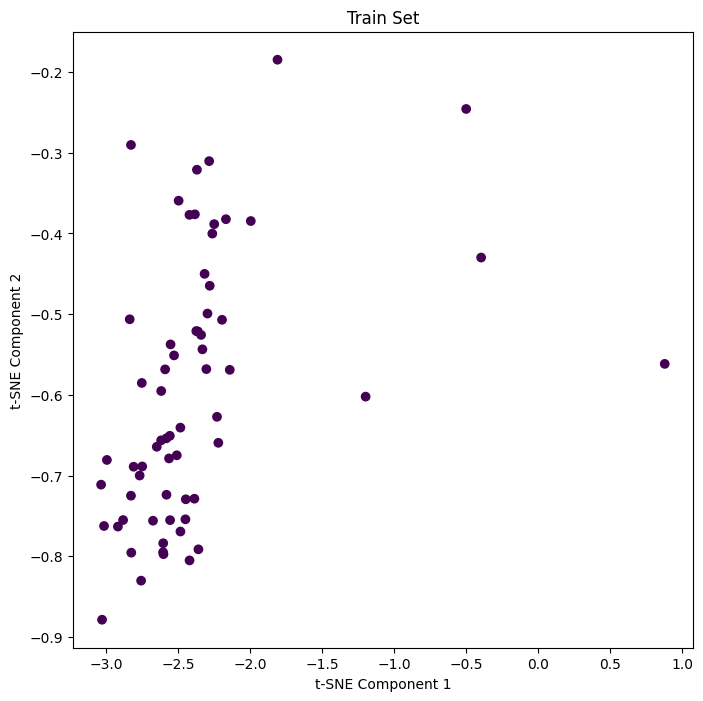

In [213]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

sc = ax.scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels_cross_kmeans, cmap='viridis')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('Train Set')
# ax[0].legend()

# ax[1].scatter(pca_result_testset[:, 0], pca_result_testset[:, 1], c=labels_test, cmap='tab10')
# # sc = ax[1].scatter(tsne_result_testset[:, 0], tsne_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
# # plt.colorbar(sc, ax=ax[1], label='cluster label')
# ax[1].set_xlabel('t-SNE Component 1')
# ax[1].set_ylabel('t-SNE Component 2')
# ax[1].set_title('Test Set')
# fig.savefig('plots/kmeans_extracted_features.png', dpi=300)
plt.show()

In [214]:
best_accuracy_cross = (labels_cross_kmeans == labels_cross.numpy()).mean()
best_accuracy_cross

np.float64(0.25)

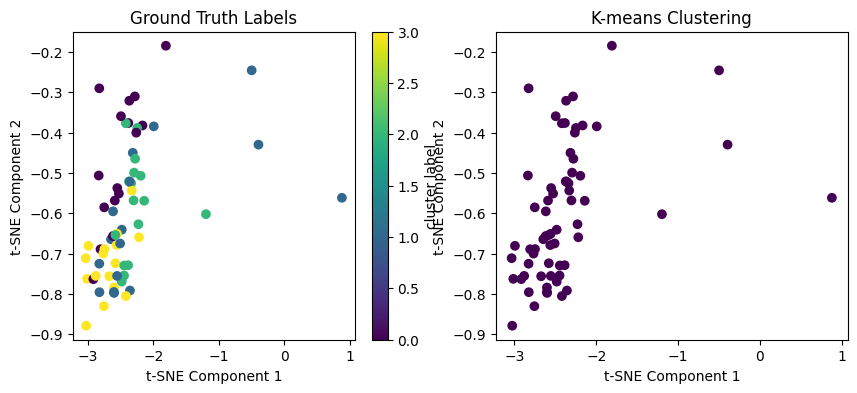

In [223]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sc = ax[0].scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels_cross, cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='cluster label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('Ground Truth Labels')
# ax[0].legend()

sc = ax[1].scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels_cross_kmeans, cmap='viridis')
# plt.colorbar(sc, ax=ax[1], label='cluster label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('K-means Clustering')
# ax[1].scatter(pca_result_testset[:, 0], pca_result_testset[:, 1], c=labels_test, cmap='tab10')
# # sc = ax[1].scatter(tsne_result_testset[:, 0], tsne_result_testset[:, 1], c=labels_test.numpy(), cmap='viridis')
# # plt.colorbar(sc, ax=ax[1], label='cluster label')
# ax[1].set_xlabel('t-SNE Component 1')
# ax[1].set_ylabel('t-SNE Component 2')
# ax[1].set_title('Test Set')
fig.savefig('plots/kmeans_extracted_features_cross.png', dpi=300)
plt.show()

## Test cross DataLoader

In [224]:
dataset_mel_cross = MelSpectrogramDataSet(
    dataset_type=DataSetType.CROSS,
    split='train',
    prefix='..'
)
# dataset_mel_cross.get_mean_and_std(dataset_mel_train)

Computing mean and std: 100%|██████████| 23808/23808 [00:13<00:00, 1735.32it/s]

Found 23808 files in folder ../data/mel_spectograms_cache/cross/train


## Cross dataset

In [153]:
# for the 
dataset_sample = SampleDataSet(dataset_type=DataSetType.CROSS, split='train',
                               prefix='..')

initializing dataset: 100%|██████████| 64/64 [00:01<00:00, 42.27it/s]


In [154]:
dataset_mel = MelSpectrogramDataSet(dataset_type=DataSetType.CROSS, split='train', prefix='..')

Computing mean and std: 100%|██████████| 23808/23808 [00:12<00:00, 1933.08it/s]

Found 23808 files in folder ../data/mel_spectograms_cache/cross/train


In [155]:
dataset_extracted = ExtractedFeaturesDataSet(
    dataset_type=DataSetType.CROSS,
    split='train',
    prefix='..'
)
dataset_extracted.from_sample_dataset(dataset_sample)
dataset_extracted.get_mel_mean_and_std(dataset_mel)

Extending config from /Users/felix/UU-Deep-Learning-2026-Assignment-2/configs/Cross/lstm/lstm_cross_8_false_1.yaml


/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(
/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [175]:
all_embeddings = []
labels = []

for i in tqdm(range(len(dataset_extracted)), total=len(dataset_extracted), desc='Embedding'):
    embeddings, label = dataset_extracted[i]
    all_embeddings.append(embeddings.unsqueeze(0))
    labels.append(label)

all_embeddings = torch.cat(all_embeddings, dim=0)
labels = torch.tensor(labels)

Embedding: 100%|██████████| 64/64 [00:39<00:00,  1.62it/s]


In [157]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)

In [158]:
pca_result_cross = pca.fit_transform(all_embeddings.detach().numpy()) # type: ignore

tsne_result_cross = tsne.fit_transform(all_embeddings.detach().numpy()) # type: ignore

pca_result_cross.shape, tsne_result_cross.shape

((64, 2), (64, 2))

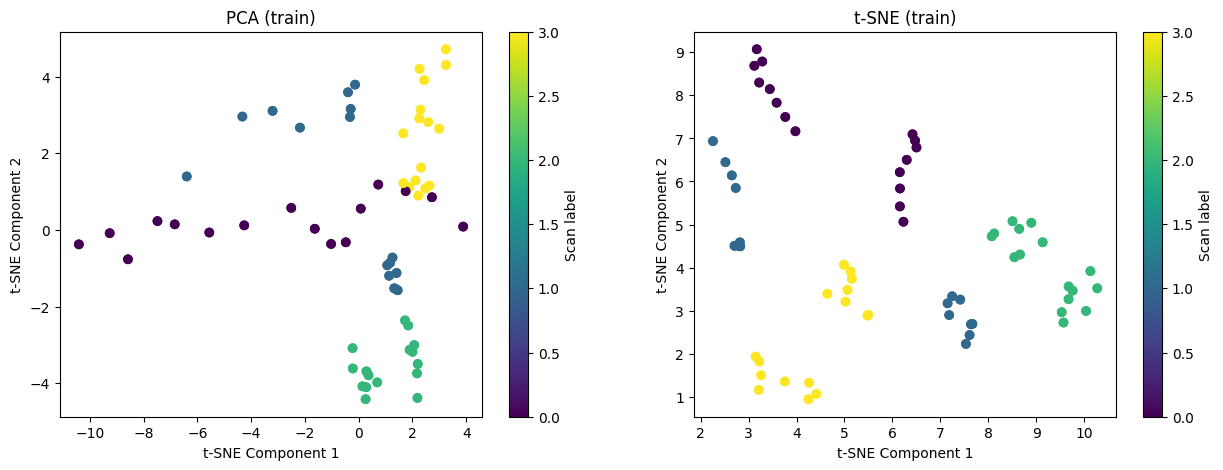

In [272]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0].scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('PCA (train)')

ax[1].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[1].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('t-SNE (train)')

fig.savefig('plots/cross_raw_values.png')

plt.show()


In [276]:
all_embeddings_avg = all_embeddings.reshape(-1, 248, 8).mean(dim=1)#.shape

pca_result_cross_avg = pca.fit_transform(all_embeddings_avg.detach().numpy()) # type: ignore

tsne_result_cross_avg = tsne.fit_transform(all_embeddings_avg.detach().numpy()) # type: ignore

pca_result_cross_avg.shape, tsne_result_cross_avg.shape

((64, 2), (64, 2))

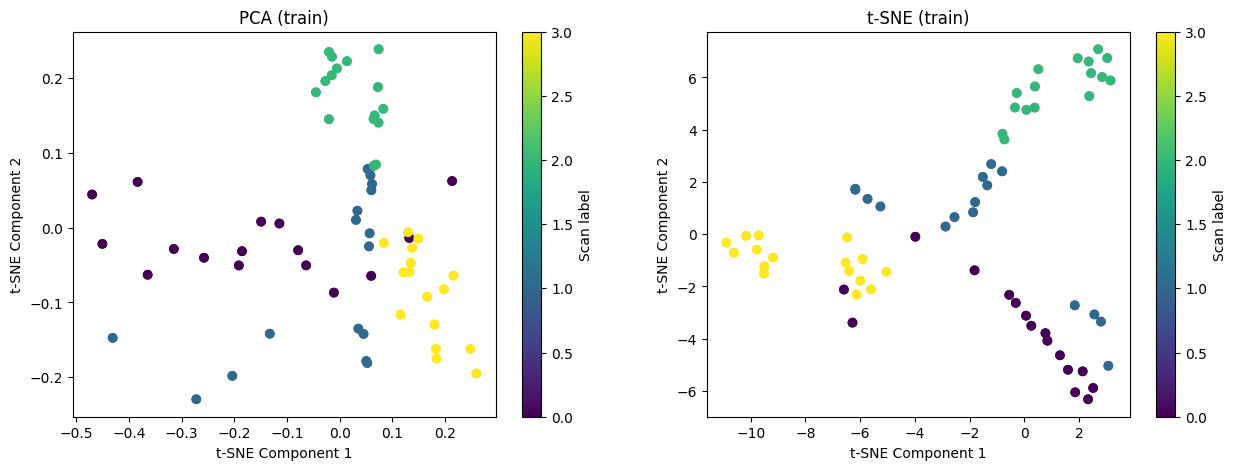

In [277]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(pca_result_cross_avg[:, 0], pca_result_cross_avg[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0].scatter(pca_result_cross_avg[:, 0], pca_result_cross_avg[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('PCA (train)')

ax[1].scatter(tsne_result_cross_avg[:, 0], tsne_result_cross_avg[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[1].scatter(tsne_result_cross_avg[:, 0], tsne_result_cross_avg[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('t-SNE (train)')

fig.savefig('plots/cross_raw_values.png')

plt.show()


### Validation Split

In [160]:
dataset_extracted_validation = ExtractedFeaturesDataSet(
    dataset_type=DataSetType.CROSS,
    split='test1',
    prefix='..'
)
dataset_extracted_validation.from_same_dataset(dataset_extracted)
# dataset_extracted.from_sample_dataset(dataset_sample)
# dataset_extracted.get_mel_mean_and_std(dataset_mel)
len(dataset_extracted_validation)

Extending config from /Users/felix/UU-Deep-Learning-2026-Assignment-2/configs/Cross/lstm/lstm_cross_8_false_1.yaml


/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(
/Users/felix/UU-Deep-Learning-2026-Assignment-2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


16

In [161]:
all_embeddings_test1 = []
labels_test1 = []

for i in tqdm(range(len(dataset_extracted_validation)), total=len(dataset_extracted_validation), desc='Embedding'):
    embeddings, label = dataset_extracted_validation[i]
    all_embeddings_test1.append(embeddings.unsqueeze(0))
    labels_test1.append(label)

all_embeddings_test1 = torch.cat(all_embeddings_test1, dim=0)
labels_test1 = torch.tensor(labels_test1)
all_embeddings_test1.shape, labels_test1.shape

Embedding:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding: 100%|██████████| 16/16 [00:08<00:00,  1.89it/s]


(torch.Size([16, 1984]), torch.Size([16]))

In [162]:
pca_result_cross_test1 = pca.transform(all_embeddings_test1.detach().numpy()) # type: ignore

n_samples = all_embeddings_test1.shape[0]
perplexity = min(30, max(1, n_samples - 1))  # Use at most 30, but less if fewer samples

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
tsne_result_cross_test1 = tsne.fit_transform(all_embeddings_test1.detach().numpy()) # type: ignore

pca_result_cross_test1.shape, tsne_result_cross_test1.shape

((16, 2), (16, 2))

In [278]:
pca_result_cross_test1_avg = pca.transform(all_embeddings_test1.reshape(-1, 248, 8).mean(dim=1).detach().numpy()) # type: ignore

n_samples = all_embeddings_test1.shape[0]
perplexity = min(30, max(1, n_samples - 1))  # Use at most 30, but less if fewer samples

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
tsne_result_cross_test1_avg = tsne.fit_transform(all_embeddings_test1.reshape(-1, 248, 8).mean(dim=1).detach().numpy()) # type: ignore

pca_result_cross_test1_avg.shape, tsne_result_cross_test1_avg.shape

((16, 2), (16, 2))

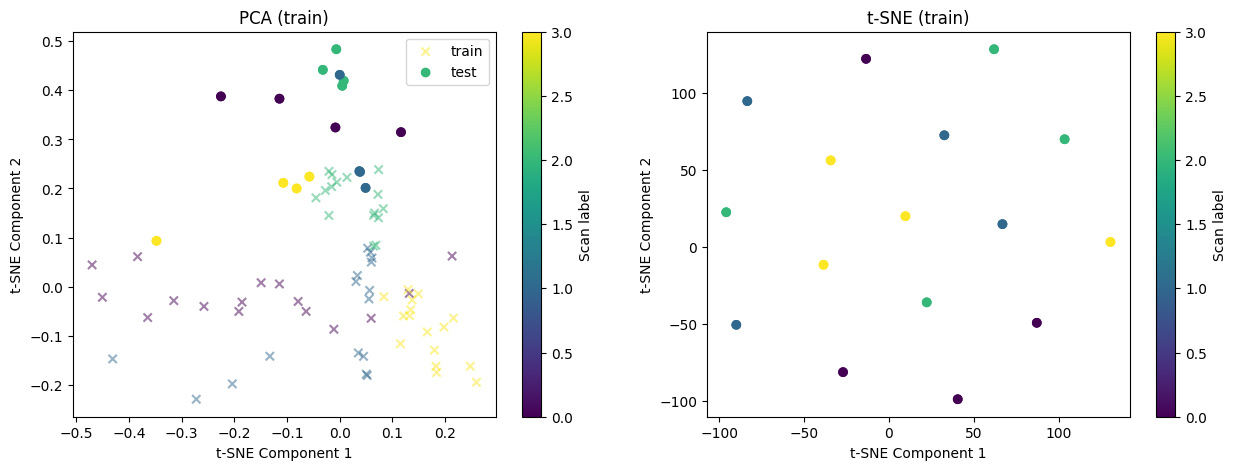

In [283]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(pca_result_cross_avg[:, 0], pca_result_cross_avg[:, 1], c=labels.numpy(), cmap='viridis', marker='x', label='train', alpha=0.5)
ax[0].scatter(pca_result_cross_test1_avg[:, 0], pca_result_cross_test1_avg[:, 1], c=labels_test1.numpy(), cmap='viridis', marker='o', label='test')
sc = ax[0].scatter(pca_result_cross_test1_avg[:, 0], pca_result_cross_test1_avg[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('PCA (train)')
ax[0].legend()

ax[1].scatter(tsne_result_cross_test1_avg[:, 0], tsne_result_cross_test1_avg[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[1].scatter(tsne_result_cross_test1_avg[:, 0], tsne_result_cross_test1_avg[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('t-SNE (train)')



plt.show()


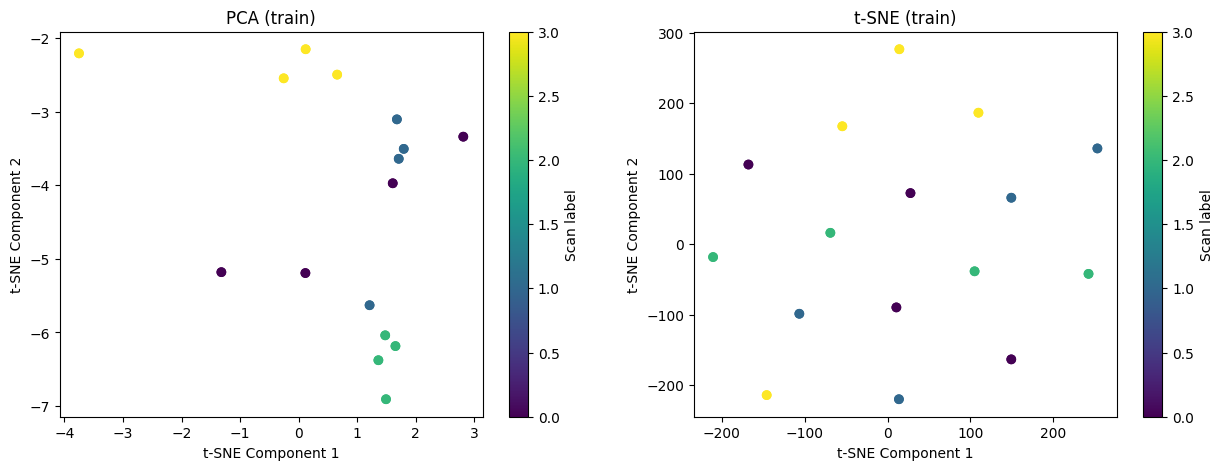

In [163]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(pca_result_cross_test1[:, 0], pca_result_cross_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[0].scatter(pca_result_cross_test1[:, 0], pca_result_cross_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('PCA (train)')

ax[1].scatter(tsne_result_cross_test1[:, 0], tsne_result_cross_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[1].scatter(tsne_result_cross_test1[:, 0], tsne_result_cross_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('t-SNE (train)')



plt.show()


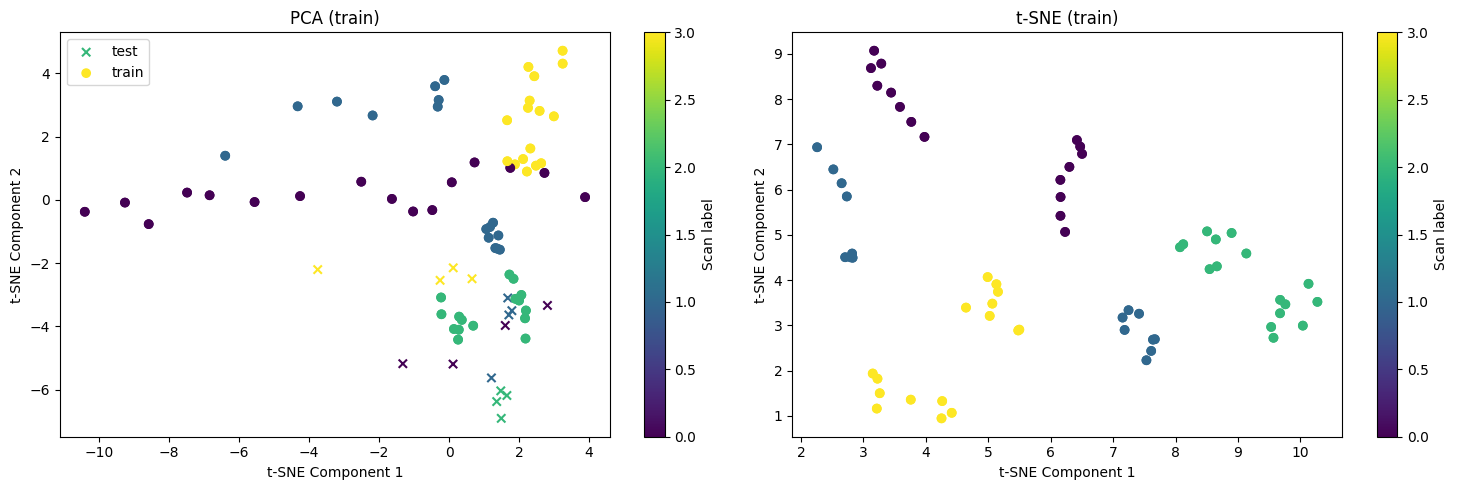

In [287]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(pca_result_cross_test1[:, 0], pca_result_cross_test1[:, 1], c=labels_test1.numpy(), cmap='viridis', marker='x', label='test')
ax[0].scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels.numpy(), cmap='viridis', marker='o', label='train')
sc = ax[0].scatter(pca_result_cross[:, 0], pca_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('PCA (train)')
ax[0].legend()

ax[1].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[1].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('t-SNE (train)')

fig.tight_layout()
fig.savefig('plots/cross_raw_values.png')

plt.show()


## Try k-means

In [164]:
from sklearn.cluster import KMeans

In [165]:
all_embeddings.shape

torch.Size([64, 1984])

In [166]:
kmeans = KMeans(n_clusters=4)

# train
kmeans.fit(all_embeddings.detach().numpy())
kmeans_labels = kmeans.labels_

# test
labels_test = kmeans.predict(all_embeddings_test1.detach().numpy())

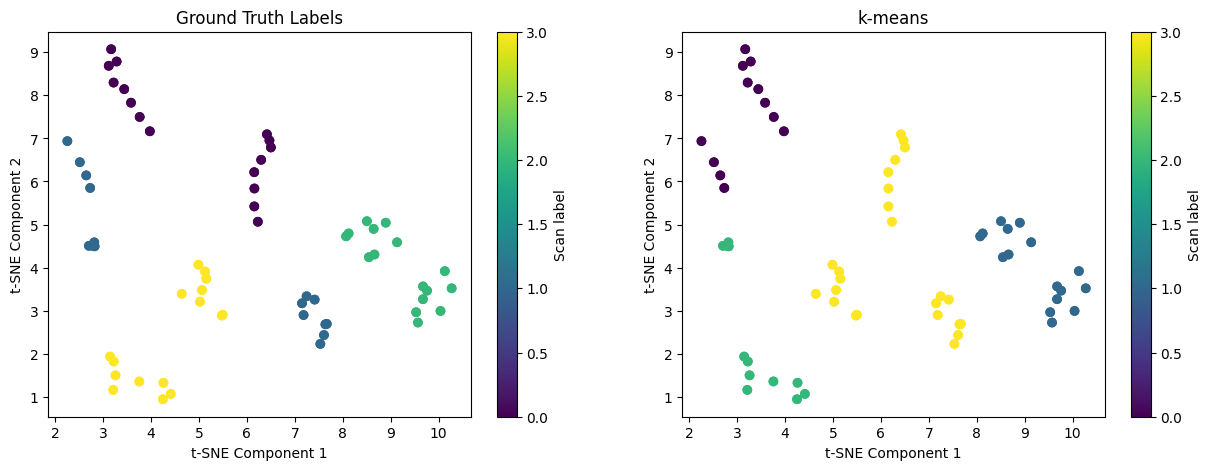

In [167]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0], label='Scan label')
ax[0].set_xlabel('t-SNE Component 1')
ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_title('Ground Truth Labels')

ax[1].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=kmeans_labels, cmap='viridis')
sc = ax[1].scatter(tsne_result_cross[:, 0], tsne_result_cross[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(sc, ax=ax[1], label='Scan label')
ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_ylabel('t-SNE Component 2')
ax[1].set_title('k-means')

plt.show()


In [168]:
# auto encoder

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

class AutoEncoderVanilla(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(AutoEncoderVanilla, self).__init__()
        self.fc1 = nn.Linear(input_size, output_size)
        # self.fc2 = nn.Linear(hidden_size, output_size)
        
        # self.fc3 = nn.Linear(output_size, hidden_size)
        self.fc4 = nn.Linear(output_size, input_size)
        
    def encode(self, x):
        # x = torch.relu(self.fc1(x))
        # x = self.fc2(x)
        x = self.fc1(x)
        return x
        
    def decode(self, x):
        # x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x
        

_auto_encoder = AutoEncoderVanilla(input_size=all_embeddings.shape[1], hidden_size=256, output_size=128)
num_parameters = sum(p.numel() for p in _auto_encoder.parameters())
print(f"Number of parameters: {num_parameters:,}")

Number of parameters: 510,016


In [ ]:
epochs = 3

optimizer = torch.optim.Adam(_auto_encoder.parameters(), lr=0.001)

train_loader = DataLoader(dataset_extracted, batch_size=8, shuffle=True)
cosine_embedding_loss = nn.CosineEmbeddingLoss()

def _expand_labels(labels: torch.Tensor, num_embeddings: int, device: torch.device) -> torch.Tensor:
    labels = labels.reshape(-1).to(device)
    if labels.numel() == num_embeddings:
        return labels

    if num_embeddings % labels.numel() != 0:
        raise ValueError(
            f"Cannot align {labels.numel()} labels with {num_embeddings} embeddings."
        )

    repeats = num_embeddings // labels.numel()
    return labels.repeat_interleave(repeats)

SCALE_RECONSTRUCTION_LOSS = 1e-2

for epoch in range(epochs):
    
    for batch in (pbar := tqdm(train_loader, total=len(train_loader), desc='Training')):
        
        x, y = batch
        # print(x, y)
        # assert x is not None and y is not None
        
        optimizer.zero_grad()
        
        # print('encoding')
        z = _auto_encoder.encode(x)
        
        x_reconstructed = _auto_encoder.decode(z)
        
        loss_reconstruction = nn.functional.mse_loss(x_reconstructed, x) # type: ignore
        
        # 2. contrastive loss (vectorized; no Python loop)
        z = z.reshape(-1, z.shape[-1])
        z = nn.functional.normalize(z, p=2, dim=1)
        _labels = _expand_labels(y, z.size(0), z.device) # type: ignore

        permutation = torch.randperm(z.size(0), device=z.device)
        targets = torch.where(_labels == _labels[permutation], 1.0, -1.0)
        loss_contrastive = cosine_embedding_loss(z, z[permutation], targets)
        
        loss = SCALE_RECONSTRUCTION_LOSS * loss_reconstruction + loss_contrastive
        
        loss.backward()
        optimizer.step()
        
        pbar.set_postfix(loss=loss.item(), loss_reconstruction=loss_reconstruction.item(), loss_contrastive=loss_contrastive.item())
        
    with torch.no_grad():
        for (x, y) in dataset_extracted_validation:
            # print('encoding')
            z = _auto_encoder.encode(x)
            
            y = torch.tensor(y)
            
            x_reconstructed = _auto_encoder.decode(z)
            
            loss_reconstruction = nn.functional.mse_loss(x_reconstructed, x) # type: ignore
            
            # 2. contrastive loss (vectorized; no Python loop)
            z = z.reshape(-1, z.shape[-1])
            z = nn.functional.normalize(z, p=2, dim=1)
            _labels = _expand_labels(y, z.size(0), z.device) # type: ignore

            permutation = torch.randperm(z.size(0), device=z.device)
            targets = torch.where(_labels == _labels[permutation], 1.0, -1.0)
            loss_contrastive = cosine_embedding_loss(z, z[permutation], targets)
            
            loss = SCALE_RECONSTRUCTION_LOSS * loss_reconstruction + loss_contrastive
            
            print(loss_reconstruction, loss_contrastive)
        

Training: 100%|██████████| 8/8 [00:35<00:00,  4.49s/it, loss=0.708, loss_contrastive=0.703, loss_reconstruction=0.498]


tensor(0.5295) tensor(0.)
tensor(0.5210) tensor(0.)
tensor(0.5421) tensor(0.)
tensor(0.5223) tensor(0.)
tensor(0.5069) tensor(0.)
tensor(0.4468) tensor(0.)
tensor(0.4456) tensor(0.)
tensor(0.4035) tensor(0.)
tensor(0.4435) tensor(0.)
tensor(0.4387) tensor(0.)
tensor(0.4076) tensor(0.)
tensor(0.4557) tensor(0.)
tensor(0.4300) tensor(0.)
tensor(0.4126) tensor(0.)
tensor(0.5168) tensor(0.)
tensor(0.5650) tensor(0.)


Training: 100%|██████████| 8/8 [00:36<00:00,  4.58s/it, loss=0.368, loss_contrastive=0.354, loss_reconstruction=1.4]  


tensor(1.6605) tensor(0.)
tensor(1.9156) tensor(0.)
tensor(1.7133) tensor(0.)
tensor(1.6567) tensor(0.)
tensor(1.7642) tensor(0.)
tensor(1.4924) tensor(0.)
tensor(1.4275) tensor(0.)
tensor(1.4925) tensor(0.)
tensor(1.4739) tensor(0.)
tensor(1.8307) tensor(0.)
tensor(1.5161) tensor(0.)
tensor(1.5646) tensor(0.)
tensor(1.4383) tensor(0.)
tensor(1.4857) tensor(0.)
tensor(1.6508) tensor(0.)
tensor(1.7383) tensor(0.)


Training: 100%|██████████| 8/8 [00:36<00:00,  4.57s/it, loss=0.598, loss_contrastive=0.591, loss_reconstruction=0.645]


tensor(0.9669) tensor(0.)
tensor(0.8041) tensor(0.)
tensor(0.9833) tensor(0.)
tensor(0.9453) tensor(0.)
tensor(0.8585) tensor(0.)
tensor(0.7700) tensor(0.)
tensor(0.8365) tensor(0.)
tensor(0.6466) tensor(0.)
tensor(0.7696) tensor(0.)
tensor(0.5753) tensor(0.)
tensor(0.6528) tensor(0.)
tensor(0.8090) tensor(0.)
tensor(0.7266) tensor(0.)
tensor(0.6914) tensor(0.)
tensor(0.9143) tensor(0.)
tensor(1.0396) tensor(0.)


torch.Size([64, 8, 248])

In [170]:
re_embeddings = []
for emb in tqdm(all_embeddings, total=len(all_embeddings), desc='Embedding'):
    with torch.no_grad():
        z = _auto_encoder.encode(emb)
        
        re_embeddings.append(z.unsqueeze(0))
        # print(emb.shape, z.shape)
        # break
        
re_embeddings_test1 = []
        
for emb in tqdm(all_embeddings_test1, total=len(all_embeddings_test1), desc='Embedding'):
    with torch.no_grad():
        z = _auto_encoder.encode(emb)
        
        re_embeddings_test1.append(z.unsqueeze(0))
        # print(emb.shape, z.shape)
        # break

Embedding: 100%|██████████| 16/16 [00:00<00:00, 25930.78it/s]


In [171]:
re_embeddings = torch.cat(re_embeddings)
re_embeddings_test1 = torch.cat(re_embeddings_test1)
re_embeddings.shape, re_embeddings_test1.shape

(torch.Size([64, 128]), torch.Size([16, 128]))

In [172]:
# compute tsne and PCA
pca = PCA(n_components=2, random_state=42)
pca_re_embeddings = pca.fit_transform(re_embeddings.numpy())
tsne = TSNE(n_components=2, random_state=42)
tsne_re_embeddings = tsne.fit_transform(re_embeddings.numpy())

pca_re_embeddings_test1 = pca.transform(re_embeddings_test1.numpy())
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(1, n_samples - 1)))
tsne_re_embeddings_test1 = tsne.fit_transform(re_embeddings_test1.numpy())

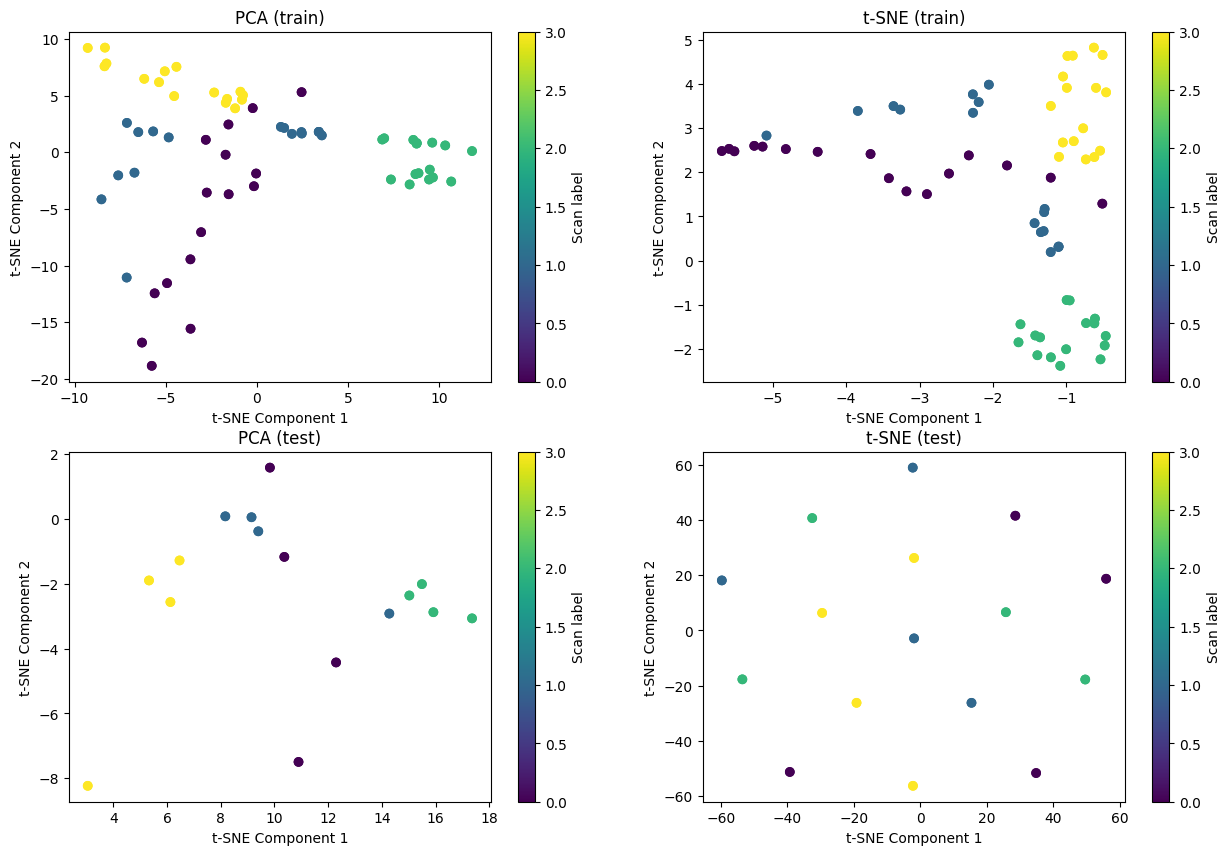

In [271]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].scatter(pca_re_embeddings[:, 0], pca_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0, 0].scatter(pca_re_embeddings[:, 0], pca_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0, 0], label='Scan label')
ax[0, 0].set_xlabel('t-SNE Component 1')
ax[0, 0].set_ylabel('t-SNE Component 2')
ax[0, 0].set_title('PCA (train)')

ax[0, 1].scatter(tsne_re_embeddings[:, 0], tsne_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0, 1].scatter(tsne_re_embeddings[:, 0], tsne_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0, 1], label='Scan label')
ax[0, 1].set_xlabel('t-SNE Component 1')
ax[0, 1].set_ylabel('t-SNE Component 2')
ax[0, 1].set_title('t-SNE (train)')

ax[1, 0].scatter(pca_re_embeddings_test1[:, 0], pca_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[1, 0].scatter(pca_re_embeddings_test1[:, 0], pca_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1, 0], label='Scan label')
ax[1, 0].set_xlabel('t-SNE Component 1')
ax[1, 0].set_ylabel('t-SNE Component 2')
ax[1, 0].set_title('PCA (test)')

ax[1, 1].scatter(tsne_re_embeddings_test1[:, 0], tsne_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[1, 1].scatter(tsne_re_embeddings_test1[:, 0], tsne_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1, 1], label='Scan label')
ax[1, 1].set_xlabel('t-SNE Component 1')
ax[1, 1].set_ylabel('t-SNE Component 2')
ax[1, 1].set_title('t-SNE (test)')

fig.savefig('cross_pca_tsne_simple.png')
plt.show()


In [181]:
# compute the k-means clustering
kmeans = KMeans(n_clusters=4)

# train
kmeans.fit(re_embeddings.detach().numpy())
kmeans_labels = kmeans.labels_

# test
labels_test = kmeans.predict(re_embeddings_test1.detach().numpy())

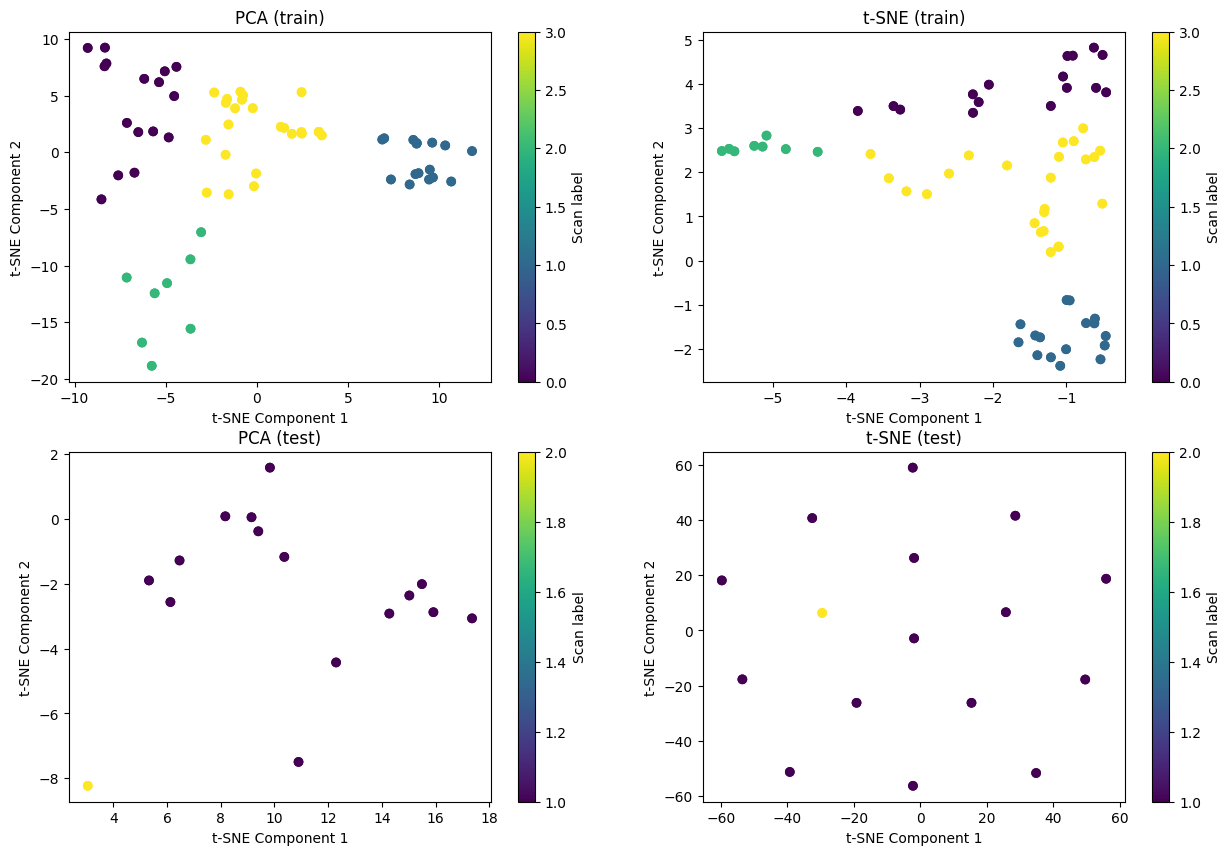

In [182]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].scatter(pca_re_embeddings[:, 0], pca_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
sc = ax[0, 0].scatter(pca_re_embeddings[:, 0], pca_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(sc, ax=ax[0, 0], label='Scan label')
ax[0, 0].set_xlabel('t-SNE Component 1')
ax[0, 0].set_ylabel('t-SNE Component 2')
ax[0, 0].set_title('PCA (train)')

ax[0, 1].scatter(tsne_re_embeddings[:, 0], tsne_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
sc = ax[0, 1].scatter(tsne_re_embeddings[:, 0], tsne_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(sc, ax=ax[0, 1], label='Scan label')
ax[0, 1].set_xlabel('t-SNE Component 1')
ax[0, 1].set_ylabel('t-SNE Component 2')
ax[0, 1].set_title('t-SNE (train)')

ax[1, 0].scatter(pca_re_embeddings_test1[:, 0], pca_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
sc = ax[1, 0].scatter(pca_re_embeddings_test1[:, 0], pca_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
plt.colorbar(sc, ax=ax[1, 0], label='Scan label')
ax[1, 0].set_xlabel('t-SNE Component 1')
ax[1, 0].set_ylabel('t-SNE Component 2')
ax[1, 0].set_title('PCA (test)')

ax[1, 1].scatter(tsne_re_embeddings_test1[:, 0], tsne_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
sc = ax[1, 1].scatter(tsne_re_embeddings_test1[:, 0], tsne_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
plt.colorbar(sc, ax=ax[1, 1], label='Scan label')
ax[1, 1].set_xlabel('t-SNE Component 1')
ax[1, 1].set_ylabel('t-SNE Component 2')
ax[1, 1].set_title('t-SNE (test)')

plt.show()


In [183]:
# logistic regression
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(re_embeddings.numpy(), labels.numpy())

print(logistic_regression.score(re_embeddings.numpy(), labels.numpy()))
logistic_regression.score(re_embeddings_test1.numpy(), labels_test1.numpy())


1.0


0.25

In [184]:
logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(all_embeddings.numpy(), labels.numpy())

print(logistic_regression.score(all_embeddings.numpy(), labels.numpy()))
logistic_regression.score(all_embeddings_test1.numpy(), labels_test1.numpy())

1.0


0.25

Average the sensor values

In [197]:
avg_emb_train = all_embeddings.reshape(-1, 248, 8).mean(dim=2)
avg_emb_test = all_embeddings_test1.reshape(-1, 248, 8).mean(dim=2)

print(avg_emb_train.shape, avg_emb_test.shape)

torch.Size([64, 248]) torch.Size([16, 248])


In [220]:
new_auto_encoder = AutoEncoderVanilla(input_size=avg_emb_train.shape[1], hidden_size=128, output_size=32)

In [221]:
1984/248

8.0

In [222]:
epochs = 10

optimizer = torch.optim.Adam(new_auto_encoder.parameters(), lr=0.01)

train_loader = DataLoader(dataset_extracted, batch_size=8, shuffle=True)
cosine_embedding_loss = nn.CosineEmbeddingLoss()

def _expand_labels(labels: torch.Tensor, num_embeddings: int, device: torch.device) -> torch.Tensor:
    labels = labels.reshape(-1).to(device)
    if labels.numel() == num_embeddings:
        return labels

    if num_embeddings % labels.numel() != 0:
        raise ValueError(
            f"Cannot align {labels.numel()} labels with {num_embeddings} embeddings."
        )

    repeats = num_embeddings // labels.numel()
    return labels.repeat_interleave(repeats)

SCALE_RECONSTRUCTION_LOSS = 1e-1

for epoch in range(epochs):
    
    avg_contrastive_loss = 0
    avg_reconstruction_loss = 0
    
    avg_contrastive_loss_test = 0
    avg_reconstruction_loss_test = 0
    
    num_train_batches = 0
    num_test_batches = 0
    
    for batch in (pbar := tqdm(train_loader, total=len(train_loader), desc='Training')):
        
        x, y = batch
        
        # print(x.shape)
        x = x.reshape(-1, 248, 8).mean(dim=2)
        # print(x.shape)
        # assert False
        # print(x, y)
        # assert x is not None and y is not None
        
        optimizer.zero_grad()
        
        # print('encoding')
        z = new_auto_encoder.encode(x)
        
        x_reconstructed = new_auto_encoder.decode(z)
        
        loss_reconstruction = nn.functional.mse_loss(x_reconstructed, x) # type: ignore
        
        # 2. contrastive loss (vectorized; no Python loop)
        z = z.reshape(-1, z.shape[-1])
        z = nn.functional.normalize(z, p=2, dim=1)
        _labels = _expand_labels(y, z.size(0), z.device) # type: ignore

        permutation = torch.randperm(z.size(0), device=z.device)
        targets = torch.where(_labels == _labels[permutation], 1.0, -1.0)
        loss_contrastive = cosine_embedding_loss(z, z[permutation], targets)
        
        loss = SCALE_RECONSTRUCTION_LOSS * loss_reconstruction + loss_contrastive
        
        loss.backward()
        optimizer.step()
        
        avg_contrastive_loss += loss_contrastive.item()
        avg_reconstruction_loss += loss_reconstruction.item()
        num_train_batches += 1
        
        pbar.set_postfix(loss=loss.item(), loss_reconstruction=f'{avg_reconstruction_loss / num_train_batches:.5f}', loss_contrastive=f'{avg_contrastive_loss / num_train_batches:.5f}')
        
        
    with torch.no_grad():
        for (x, y) in dataset_extracted_validation:
            # print('encoding')
            
            x = x.reshape(-1, 248, 8).mean(dim=2)
            
            z = new_auto_encoder.encode(x)
            
            y = torch.tensor(y)
            
            x_reconstructed = new_auto_encoder.decode(z)
            
            loss_reconstruction = nn.functional.mse_loss(x_reconstructed, x) # type: ignore
            
            # 2. contrastive loss (vectorized; no Python loop)
            z = z.reshape(-1, z.shape[-1])
            z = nn.functional.normalize(z, p=2, dim=1)
            _labels = _expand_labels(y, z.size(0), z.device) # type: ignore

            permutation = torch.randperm(z.size(0), device=z.device)
            targets = torch.where(_labels == _labels[permutation], 1.0, -1.0)
            loss_contrastive = cosine_embedding_loss(z, z[permutation], targets)
            
            avg_contrastive_loss_test += loss_contrastive.item()
            avg_reconstruction_loss_test += loss_reconstruction.item()
            num_test_batches += 1
            
            loss = SCALE_RECONSTRUCTION_LOSS * loss_reconstruction + loss_contrastive
            
            print(avg_reconstruction_loss_test / num_test_batches, avg_contrastive_loss_test / num_test_batches)
        

Training:   0%|          | 0/8 [00:00<?, ?it/s]

Training: 100%|██████████| 8/8 [00:36<00:00,  4.50s/it, loss=0.513, loss_contrastive=0.35473, loss_reconstruction=0.01329] 


0.004605548921972513 0.0
0.005546496715396643 0.0
0.005298787883172433 0.0
0.005123888025991619 0.0
0.005218603927642107 0.0
0.005223632014046113 0.0
0.00547362830755966 0.0
0.0057287082890979946 0.0
0.005654360374642743 0.0
0.006460538879036903 0.0
0.006485566877844659 0.0
0.006507351684073607 0.0
0.006413807447713155 0.0
0.0064531980148915735 0.0
0.006320633149395387 0.0
0.006206699996255338 0.0


Training: 100%|██████████| 8/8 [00:35<00:00,  4.50s/it, loss=0.0337, loss_contrastive=0.20729, loss_reconstruction=0.00617]


0.004399578087031841 0.0
0.005358795402571559 0.0
0.005242901078114907 0.0
0.004829907906241715 0.0
0.0048071700148284435 0.0
0.0047744461335241795 0.0
0.004752586928329298 0.0
0.004890152893494815 0.0
0.004883065250598722 0.0
0.005135870166122913 0.0
0.005182088183408434 0.0
0.005160063466367622 0.0
0.00512722242050446 0.0
0.005148739420941898 0.0
0.005050455251087745 0.0
0.004956573277013376 0.0


...

0.0017144440207630396 0.0
0.0018095817649737 0.0
0.0017616877642770608 0.0
0.001735919591737911 0.0
0.001883690315298736 0.0
0.0019309705627771716 0.0
0.002039438995000507 0.0
0.0020345846860436723 0.0
0.0020358793101169998 0.0
0.002028467075433582 0.0
0.0020033506337891927 0.0
0.0020126182741175094 0.0
0.0020347442836142504 0.0
0.002043146889523736 0.0
0.0020251219083244603 0.0
0.0019914931326638907 0.0


Training: 100%|██████████| 8/8 [00:35<00:00,  4.41s/it, loss=0.000201, loss_contrastive=0.04932, loss_reconstruction=0.00167]


0.0017815239261835814 0.0
0.001925954013131559 0.0
0.0018922242258364956 0.0
0.0018241388897877187 0.0
0.00198168873321265 0.0
0.0020681858877651393 0.0
0.002176217019690999 0.0
0.0021634270233334973 0.0
0.0021741852397099137 0.0
0.002176523383241147 0.0
0.002133216380819001 0.0
0.0021508290568211428 0.0
0.0021824280713469936 0.0
0.0021870374330319464 0.0
0.0021696646464988588 0.0
0.002130429580574855 0.0


Training: 100%|██████████| 8/8 [00:35<00:00,  4.44s/it, loss=0.0523, loss_contrastive=0.02696, loss_reconstruction=0.00188]  


0.0014245788333937526 0.0
0.0015775461215525866 0.0
0.0015377379798640807 0.0
0.0014748095709364861 0.0
0.0016261069802567362 0.0
0.0017128709587268531 0.0
0.0018678631999396852 0.0
0.0019018809398403391 0.0
0.0019178597334151466 0.0
0.0019357118871994317 0.0
0.0019130834949795496 0.0
0.0019308052433189005 0.0
0.0019586910045920657 0.0
0.00199169764528051 0.0
0.0019701531001677115 0.0
0.001918395166285336 0.0


In [223]:
re_re_embeddings_train = []
for emb in tqdm(all_embeddings, total=len(all_embeddings), desc='Embedding train'):
    with torch.no_grad():
        emb = emb.reshape(-1, 248, 8).mean(dim=2)
        z = new_auto_encoder.encode(emb)
        
        re_re_embeddings_train.append(z)
        
re_re_embeddings_test1 = []
for emb in tqdm(all_embeddings_test1, total=len(all_embeddings_test1), desc='Embedding test'):
    with torch.no_grad():
        emb = emb.reshape(-1, 248, 8).mean(dim=2)
        z = new_auto_encoder.encode(emb)
        
        re_re_embeddings_test1.append(z)
        

re_re_embeddings = torch.cat(re_re_embeddings_train)
re_re_embeddings_test1 = torch.cat(re_re_embeddings_test1)

print(re_re_embeddings.shape, re_re_embeddings_test1.shape)

Embedding test: 100%|██████████| 16/16 [00:00<00:00, 26358.55it/s]

torch.Size([64, 32]) torch.Size([16, 32])


In [224]:
# dimensionality reduction
pca = PCA(n_components=2, random_state=42)
pca_re_re_embeddings = pca.fit_transform(re_re_embeddings.numpy())
tsne = TSNE(n_components=2, random_state=42)
tsne_re_re_embeddings = tsne.fit_transform(re_re_embeddings.numpy())

pca_re_re_embeddings_test1 = pca.transform(re_re_embeddings_test1.numpy())
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(1, n_samples - 1)))
tsne_re_re_embeddings_test1 = tsne.fit_transform(re_re_embeddings_test1.numpy())

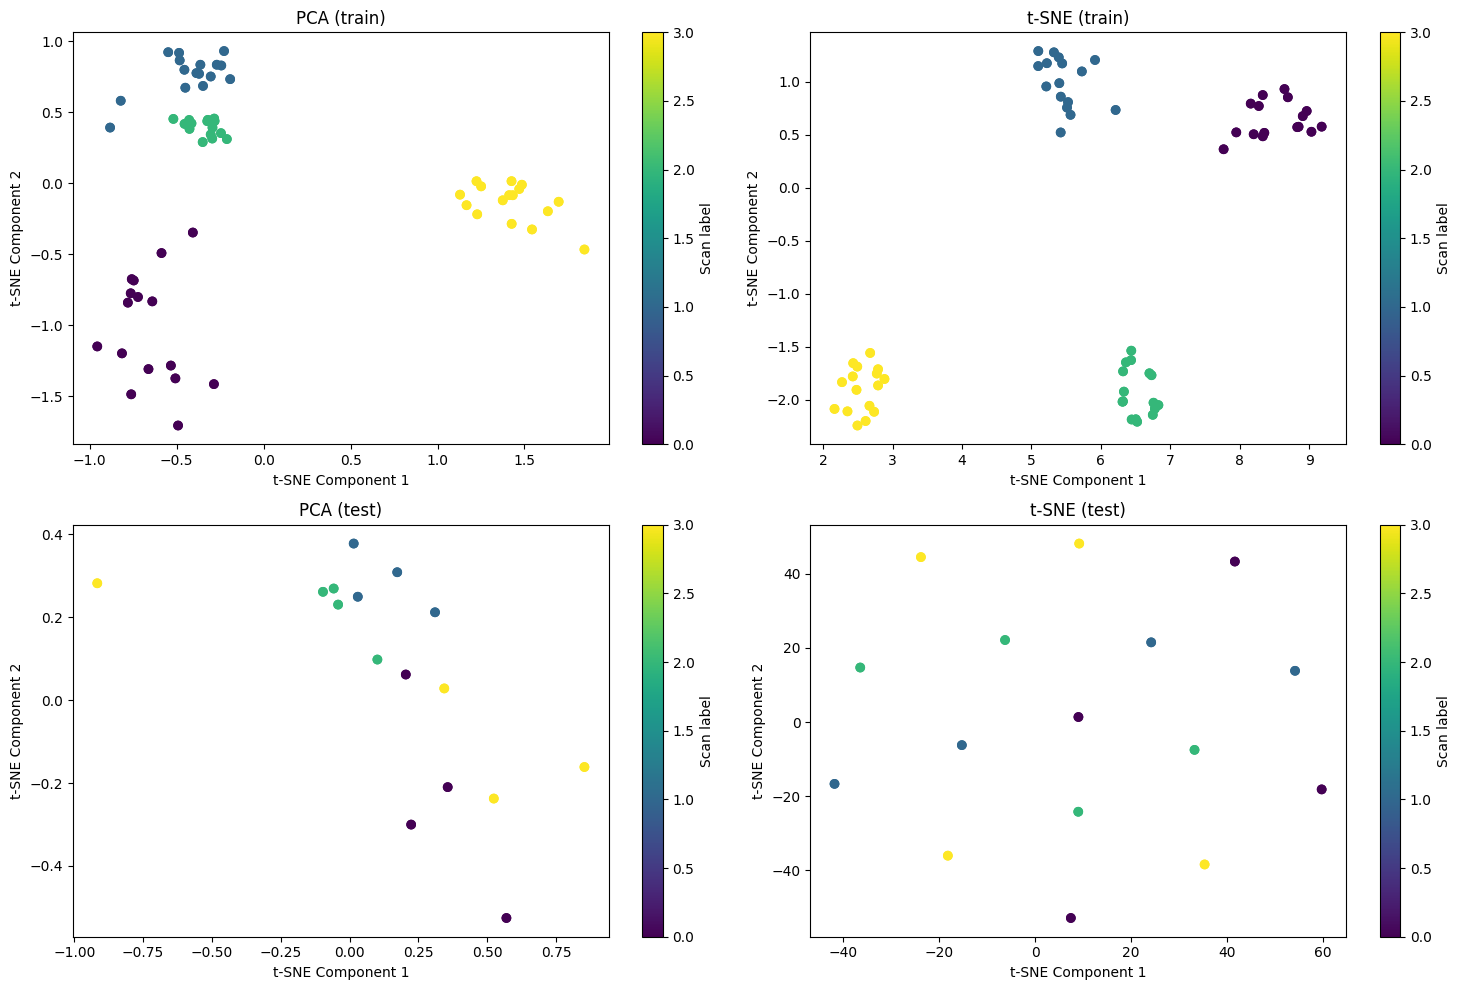

In [290]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].scatter(pca_re_re_embeddings[:, 0], pca_re_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0, 0].scatter(pca_re_re_embeddings[:, 0], pca_re_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0, 0], label='Scan label')
ax[0, 0].set_xlabel('t-SNE Component 1')
ax[0, 0].set_ylabel('t-SNE Component 2')
ax[0, 0].set_title('PCA (train)')

ax[0, 1].scatter(tsne_re_re_embeddings[:, 0], tsne_re_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
sc = ax[0, 1].scatter(tsne_re_re_embeddings[:, 0], tsne_re_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[0, 1], label='Scan label')
ax[0, 1].set_xlabel('t-SNE Component 1')
ax[0, 1].set_ylabel('t-SNE Component 2')
ax[0, 1].set_title('t-SNE (train)')

ax[1, 0].scatter(pca_re_re_embeddings_test1[:, 0], pca_re_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[1, 0].scatter(pca_re_re_embeddings_test1[:, 0], pca_re_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1, 0], label='Scan label')
ax[1, 0].set_xlabel('t-SNE Component 1')
ax[1, 0].set_ylabel('t-SNE Component 2')
ax[1, 0].set_title('PCA (test)')

ax[1, 1].scatter(tsne_re_re_embeddings_test1[:, 0], tsne_re_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
sc = ax[1, 1].scatter(tsne_re_re_embeddings_test1[:, 0], tsne_re_re_embeddings_test1[:, 1], c=labels_test1.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax[1, 1], label='Scan label')
ax[1, 1].set_xlabel('t-SNE Component 1')
ax[1, 1].set_ylabel('t-SNE Component 2')
ax[1, 1].set_title('t-SNE (test)')

fig.tight_layout()
fig.savefig('plots/dim_reduced_cross_autoencoder.png')

plt.show()


In [226]:
# compute the k-means clustering
kmeans = KMeans(n_clusters=4)

# train
kmeans.fit(re_re_embeddings.detach().numpy())
kmeans_labels = kmeans.labels_

# test
labels_test = kmeans.predict(re_re_embeddings_test1.detach().numpy())

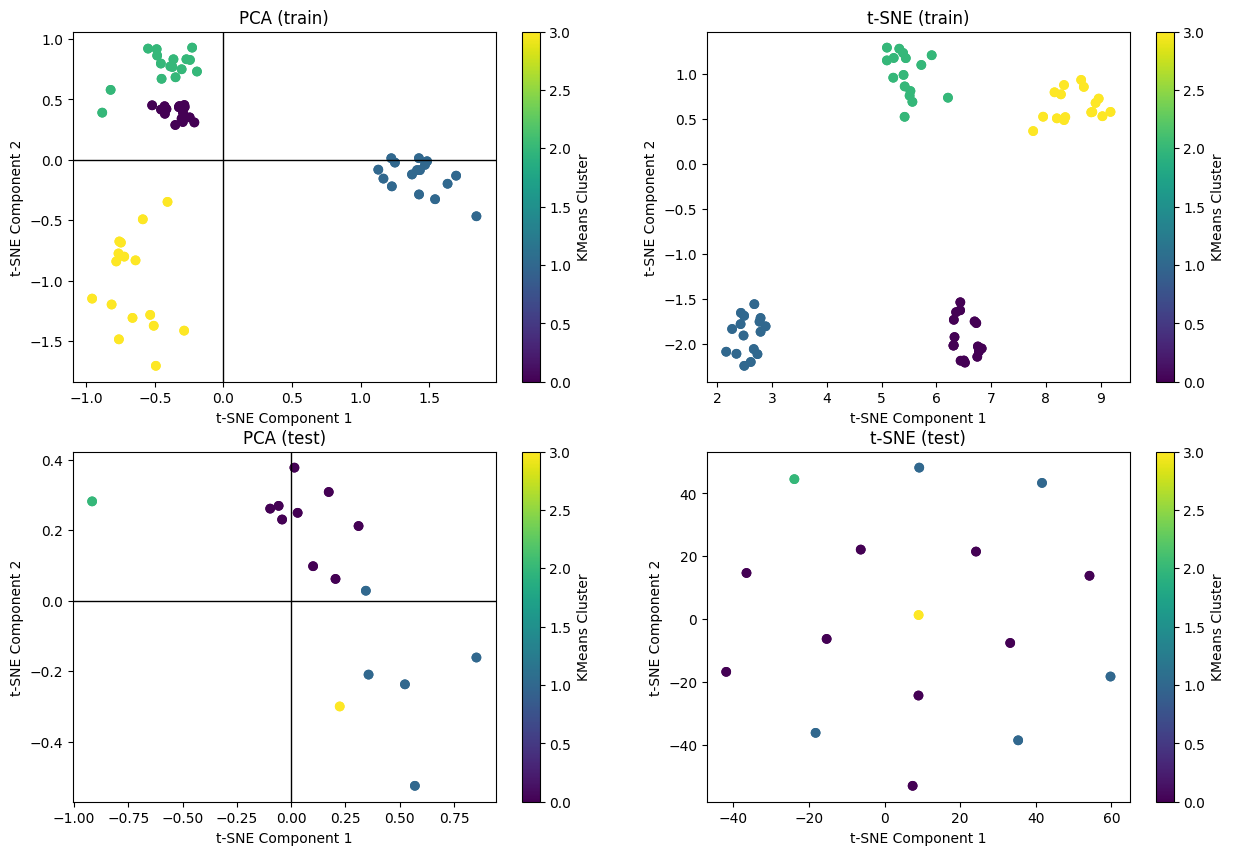

In [268]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Train PCA with KMeans labels
ax[0, 0].scatter(pca_re_re_embeddings[:, 0], pca_re_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
sc = ax[0, 0].scatter(pca_re_re_embeddings[:, 0], pca_re_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(sc, ax=ax[0, 0], label='KMeans Cluster')
ax[0, 0].set_xlabel('t-SNE Component 1')
ax[0, 0].set_ylabel('t-SNE Component 2')
ax[0, 0].set_title('PCA (train)')

ax[0, 0].axhline(0, color='black', linestyle='-', linewidth=1)
ax[0, 0].axvline(0, color='black', linestyle='-', linewidth=1)

# Train t-SNE with KMeans labels
ax[0, 1].scatter(tsne_re_re_embeddings[:, 0], tsne_re_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
sc = ax[0, 1].scatter(tsne_re_re_embeddings[:, 0], tsne_re_re_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(sc, ax=ax[0, 1], label='KMeans Cluster')
ax[0, 1].set_xlabel('t-SNE Component 1')
ax[0, 1].set_ylabel('t-SNE Component 2')
ax[0, 1].set_title('t-SNE (train)')

# Test PCA with predicted KMeans clusters
ax[1, 0].scatter(pca_re_re_embeddings_test1[:, 0], pca_re_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
sc = ax[1, 0].scatter(pca_re_re_embeddings_test1[:, 0], pca_re_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
plt.colorbar(sc, ax=ax[1, 0], label='KMeans Cluster')
ax[1, 0].set_xlabel('t-SNE Component 1')
ax[1, 0].set_ylabel('t-SNE Component 2')
ax[1, 0].set_title('PCA (test)')

ax[1, 0].axhline(0, color='black', linestyle='-', linewidth=1)
ax[1, 0].axvline(0, color='black', linestyle='-', linewidth=1)

# Test t-SNE with predicted KMeans clusters
ax[1, 1].scatter(tsne_re_re_embeddings_test1[:, 0], tsne_re_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
sc = ax[1, 1].scatter(tsne_re_re_embeddings_test1[:, 0], tsne_re_re_embeddings_test1[:, 1], c=labels_test, cmap='viridis')
plt.colorbar(sc, ax=ax[1, 1], label='KMeans Cluster')
ax[1, 1].set_xlabel('t-SNE Component 1')
ax[1, 1].set_ylabel('t-SNE Component 2')
ax[1, 1].set_title('t-SNE (test)')

plt.show()


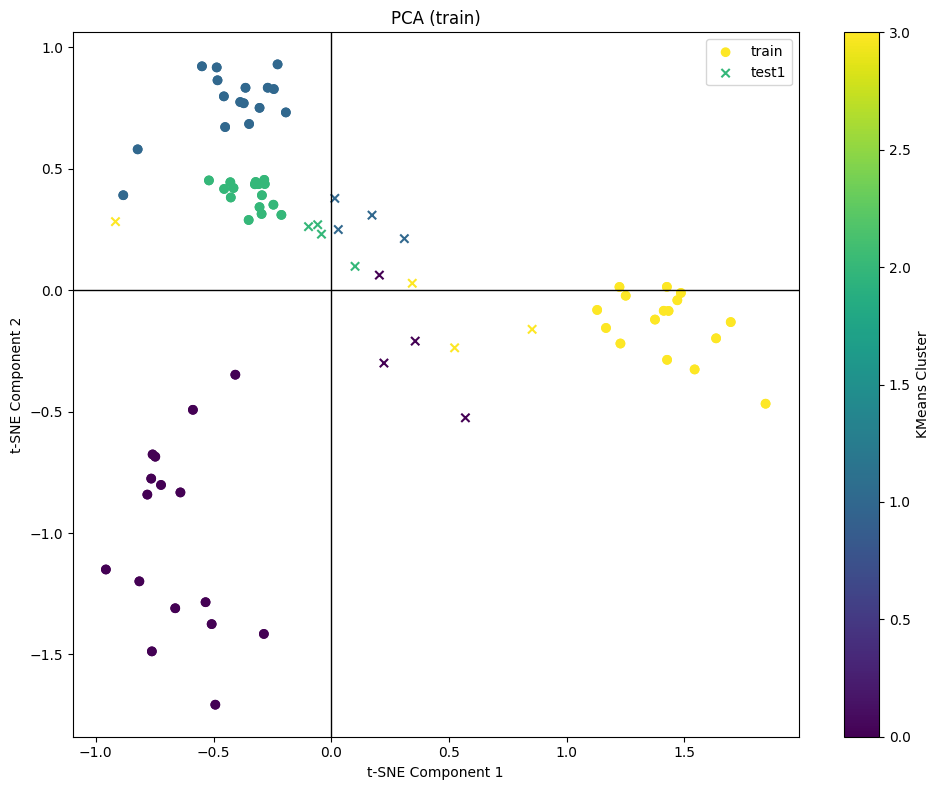

In [295]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Train PCA with KMeans labels
ax.scatter(pca_re_re_embeddings[:, 0], pca_re_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis', marker='o', label='train')
sc = ax.scatter(pca_re_re_embeddings[:, 0], pca_re_re_embeddings[:, 1], c=labels.numpy(), cmap='viridis')
plt.colorbar(sc, ax=ax, label='KMeans Cluster')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('PCA (train)')

ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.axvline(0, color='black', linestyle='-', linewidth=1)


ax.scatter(pca_re_re_embeddings_test1[:, 0], pca_re_re_embeddings_test1[:, 1], c=labels_test1, cmap='viridis', marker='x', label='test1')

ax.legend()

fig.tight_layout()
fig.savefig('plots/cross_pca_ground_truth.png')

plt.show()


In [235]:
re_re_embeddings_all = torch.cat([re_re_embeddings, re_re_embeddings_test1])
re_re_embeddings_all.shape

torch.Size([80, 32])

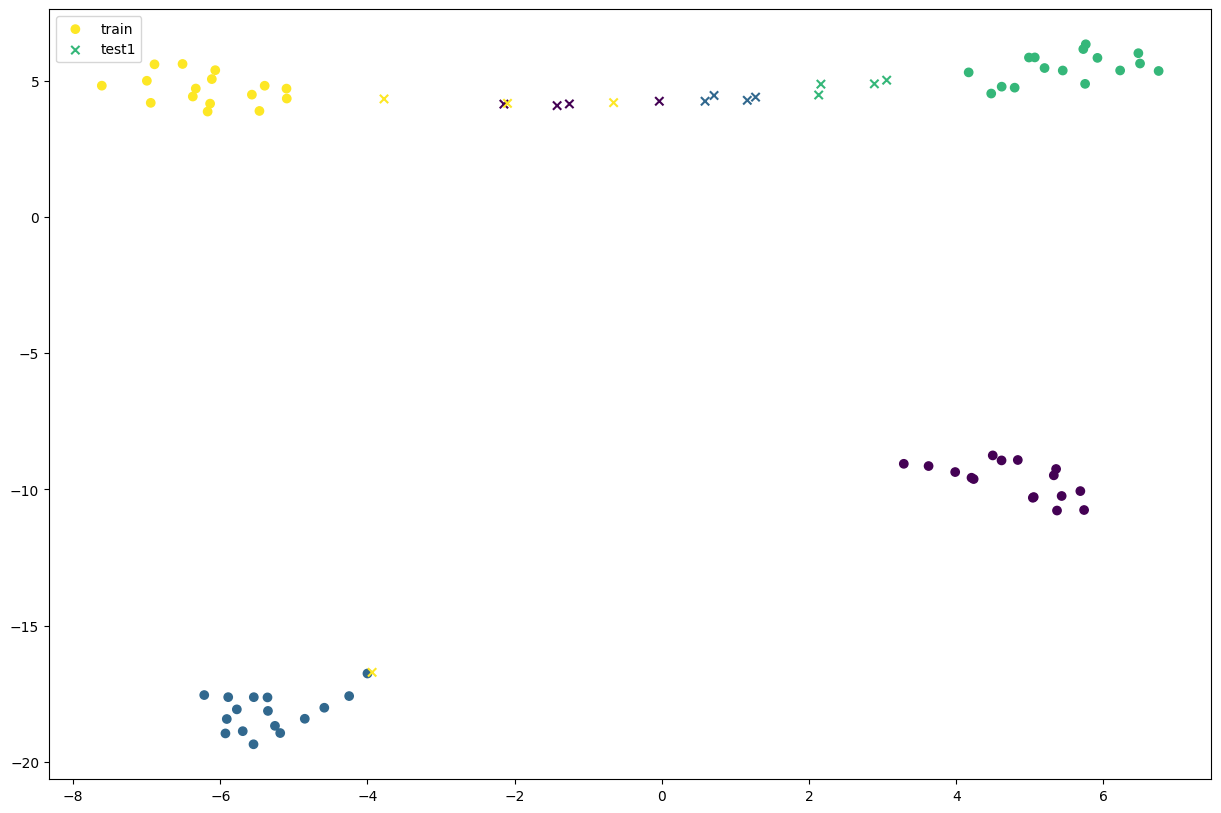

In [237]:
tsne_embeddings_all = tsne.fit_transform(re_re_embeddings_all.numpy())

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.scatter(tsne_embeddings_all[:len(re_re_embeddings), 0], tsne_embeddings_all[:len(re_re_embeddings), 1], c=labels.numpy(), cmap='viridis', marker='o', label='train')
ax.scatter(tsne_embeddings_all[len(re_re_embeddings):, 0], tsne_embeddings_all[len(re_re_embeddings):, 1], c=labels_test1.numpy(), cmap='viridis', marker='x', label='test1')

ax.legend()

plt.show()




In [ ]:
from sklearn.neighbors import NearestNeighbors

# Use the concatenated embeddings for kNN (re_re_embeddings_all)
# Assume re_re_embeddings and re_re_embeddings_test1 are in the same latent space

k_values = [1, 2, 3, 4, 5, 7]
knn_results = {}
accuracies = {}

for k in k_values:
    # Fit kNN on the training data
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(pca_re_re_embeddings)
    
    # Query neighbors for the test1 set
    distances, indices = knn.kneighbors(pca_re_re_embeddings_test1)
    knn_results[k] = {
        'distances': distances,
        'indices': indices
    }

    correct = 0
    total = len(re_re_embeddings_test1)

    for i in range(total):
        neighbor_labels = labels[indices[i]]
        unique_labels, counts = torch.unique(neighbor_labels, return_counts=True)
        predicted_label = unique_labels[counts.argmax()].item()
        if predicted_label == labels_test1[i].item():
            correct += 1

    accuracy = correct / total
    accuracies[k] = accuracy
    print(f"k={k} accuracy: {accuracy:.4f}")

# Optionally print accuracies for all k
print("kNN Accuracies for each k:", accuracies)

k=1 accuracy: 0.4375
k=2 accuracy: 0.5000
k=3 accuracy: 0.4375
k=4 accuracy: 0.3750
k=5 accuracy: 0.3750
k=7 accuracy: 0.3750
kNN Accuracies for each k: {1: 0.4375, 2: 0.5, 3: 0.4375, 4: 0.375, 5: 0.375, 7: 0.375}


In [247]:
from torchvision.ops import MLP

In [252]:
mlp = MLP(in_channels=re_re_embeddings.shape[1], hidden_channels=[32, 16, 16], norm_layer=nn.BatchNorm1d, activation_layer=nn.ReLU, dropout=0.1)

In [264]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Prepare data
X_train = re_re_embeddings
y_train = labels

# You need to define validation set embeddings & labels (here assumed as re_re_embeddings_val, labels_val)
X_val = re_re_embeddings_test1
y_val = labels_test1

batch_size = 8

# Create TensorDataset and DataLoader for training
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp = mlp.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
num_epochs = 30

X_val = X_val.to(device)
y_val = y_val.to(device)

for epoch in range(num_epochs):
    mlp.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = mlp(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    avg_loss = running_loss / len(train_loader.dataset)

    # Validation step: use all validation embeddings
    mlp.eval()
    with torch.no_grad():
        val_outputs = mlp(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_pred = val_outputs.argmax(dim=1)
        val_acc = (val_pred == y_val).float().mean().item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")
 

Epoch 1/30, Train Loss: 0.6117, Val Loss: 4.4479, Val Acc: 0.4375
Epoch 5/30, Train Loss: 0.1774, Val Loss: 4.3161, Val Acc: 0.5000
Epoch 10/30, Train Loss: 0.3379, Val Loss: 3.7944, Val Acc: 0.5000
Epoch 15/30, Train Loss: 0.1811, Val Loss: 4.0868, Val Acc: 0.4375
Epoch 20/30, Train Loss: 0.3045, Val Loss: 3.9308, Val Acc: 0.5000
Epoch 25/30, Train Loss: 0.1059, Val Loss: 3.8216, Val Acc: 0.5000
Epoch 30/30, Train Loss: 0.2382, Val Loss: 4.0803, Val Acc: 0.4375
